# FERM Presentation Results

This notebook is a clean presentation workflow for comparing:

- **RM**: neutral radiation baseline;
- **Traditional FERM**: destination-level GDP attractiveness;
- **Relational FERM**: corridor-specific CEPII bilateral features;
- **Abel-FERM**: historical migrant-stock dyadic affinity using the final one-parameter Option B construction.

The presentation logic is:

1. Define the common radiation mechanism and feature-specific \(\Sigma\) matrices.
2. Tune only the model variance parameter \(\sigma\) on the calibration split (`validation_2019_h1` in the dataset labels).
3. Evaluate once on `test_2019_h2`.
4. Compare models globally and route-by-route.
5. Identify where each feature helps or hurts.

## 0. Run Controls

Use `FAST_MODE=True` while preparing slides. Switch it off only for the final numbers.

The important methodological point: **all feature specifications are compared with the same radiation mechanism; only the \(\Sigma\) matrix changes.**

In [252]:
from pathlib import Path
import os

# Keep matplotlib cache local so imports are faster/reproducible on this machine.
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

FAST_MODE = True
SAVE_FIGURES = True
FIG_DIR = Path("outputs/presentation_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CONTINENT = "Asia"
CALIBRATION_LABEL = "validation_2019_h1"
TEST_LABEL = "test_2019_h2"
RELATIONAL_FEATURE_YEAR = 2019
ABEL_SHEET = "2005-10"
DISTANCE_COL = "dist"

# Final run suggestion: FAST_MODE=False, NUM_PARTICLES_FULL=5000000.
NUM_PARTICLES_FAST = 5000000
NUM_PARTICLES_FULL = 5000000
NUM_PARTICLES = NUM_PARTICLES_FAST if FAST_MODE else NUM_PARTICLES_FULL

SIGMA_GRID_FAST = [0.5, 1.0, 2.0, 5.0, 8.0]
SIGMA_GRID_FULL = [0.25, 0.5, 1.0, 2.0, 5.0, 8.0, 12.0]
SIGMA_GRID = SIGMA_GRID_FAST if FAST_MODE else SIGMA_GRID_FULL

print(f"FAST_MODE={FAST_MODE}")
print(f"NUM_PARTICLES={NUM_PARTICLES}")
print(f"SIGMA_GRID={SIGMA_GRID}")

FAST_MODE=True
NUM_PARTICLES=5000000
SIGMA_GRID=[0.5, 1.0, 2.0, 5.0, 8.0]


## 1. Imports and Helper Functions

This section defines all model wrappers and plotting utilities used below. The helper functions are intentionally local to this notebook so the presentation can be rerun cleanly.

In [253]:
import importlib
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.ferm.model as ferm_model
importlib.reload(ferm_model)
from src.ferm.model import FERM, RM
from src.ferm.config import Config
from src.ferm.preprocessing import filter_flows_by_continent, split_flows_by_period
from src.ferm.utils import (
    add_niche,
    build_master_country_table,
    load_country_geometries_global,
    load_migration_data,
    load_niche_data,
    load_population_data,
    prepare_nodes,
)

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "font.size": 11,
})

EPS = 1.0


def savefig(name: str):
    if SAVE_FIGURES:
        path = FIG_DIR / f"{name}.png"
        plt.savefig(path, dpi=220, bbox_inches="tight")
        print(f"saved: {path}")


def log10p(x):
    return np.log10(np.asarray(x, dtype=float) + 1.0)




def predictive_r2_from_logs(obs_log, pred_log):
    obs_log = np.asarray(obs_log, dtype=float)
    pred_log = np.asarray(pred_log, dtype=float)
    mask = np.isfinite(obs_log) & np.isfinite(pred_log)
    obs_log = obs_log[mask]
    pred_log = pred_log[mask]
    if len(obs_log) == 0:
        return np.nan
    ss_res = np.sum((obs_log - pred_log) ** 2)
    ss_tot = np.sum((obs_log - obs_log.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan


def route_r2_log_gain_vs_rm(route_df: pd.DataFrame, model_name: str) -> tuple[float, float, float]:
    obs_log = log10p(route_df["num_migrants"])
    rm_log = log10p(route_df["pred_rm"])
    model_log = log10p(route_df[f"pred_{model_name}"])
    r2_rm = predictive_r2_from_logs(obs_log, rm_log)
    r2_model = predictive_r2_from_logs(obs_log, model_log)
    return r2_model - r2_rm, r2_model, r2_rm


def prepare_comp(comp: pd.DataFrame) -> pd.DataFrame:
    out = comp.copy()
    if "total_migrants" in out.columns and "num_migrants" not in out.columns:
        out = out.rename(columns={"total_migrants": "num_migrants"})
    if "residual" not in out.columns:
        out["residual"] = out["predicted_migrants"] - out["num_migrants"]
    if "abs_error" not in out.columns:
        out["abs_error"] = out["residual"].abs()
    if "log_ratio" not in out.columns:
        out["log_ratio"] = np.log10((out["predicted_migrants"] + EPS) / (out["num_migrants"] + EPS))
    if "abs_log_ratio" not in out.columns:
        out["abs_log_ratio"] = out["log_ratio"].abs()
    return out


def compare_to_rm(comp_rm: pd.DataFrame, comp_model: pd.DataFrame, model_name: str) -> pd.DataFrame:
    rm = prepare_comp(comp_rm)
    model = prepare_comp(comp_model)
    keep_rm = ["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants", "predicted_migrants", "abs_log_ratio", "abs_error"]
    keep_model = ["country_from", "country_to", "predicted_migrants", "abs_log_ratio", "abs_error", "log_ratio"]
    rm = rm[keep_rm].rename(columns={
        "predicted_migrants": "pred_rm",
        "abs_log_ratio": "abs_log_rm",
        "abs_error": "abs_error_rm",
    })
    model = model[keep_model].rename(columns={
        "predicted_migrants": f"pred_{model_name}",
        "abs_log_ratio": f"abs_log_{model_name}",
        "abs_error": f"abs_error_{model_name}",
        "log_ratio": f"log_ratio_{model_name}",
    })
    out = rm.merge(model, on=["country_from", "country_to"], how="inner")
    out["model"] = model_name
    out["improvement_abs_log"] = out["abs_log_rm"] - out[f"abs_log_{model_name}"]
    out["improvement_abs_error"] = out["abs_error_rm"] - out[f"abs_error_{model_name}"]
    out["log_shift_vs_rm"] = log10p(out[f"pred_{model_name}"]) - log10p(out["pred_rm"])
    return out


def summarize_against_observed(comp: pd.DataFrame, label: str, family: str, sigma=None) -> dict:
    c = prepare_comp(comp)
    obs_log = log10p(c["num_migrants"])
    pred_log = log10p(c["predicted_migrants"])
    return {
        "model": label,
        "family": family,
        "sigma": sigma,
        "pairs": len(c),
        "observed_total": c["num_migrants"].sum(),
        "predicted_total": c["predicted_migrants"].sum(),
        "MAE": c["abs_error"].mean(),
        "RMSE": np.sqrt(np.mean((c["predicted_migrants"] - c["num_migrants"]) ** 2)),
        "Pearson_log": pd.Series(obs_log).corr(pd.Series(pred_log), method="pearson"),
        "Spearman_log": pd.Series(obs_log).corr(pd.Series(pred_log), method="spearman"),
        "R2_log": predictive_r2_from_logs(obs_log, pred_log),
        "Median_abs_log_ratio": c["abs_log_ratio"].median(),
        "Mean_abs_log_ratio": c["abs_log_ratio"].mean(),
        "zero_pred_share": (c["predicted_migrants"] <= 0).mean(),
        "zero_pred_observed_total": c.loc[c["predicted_migrants"] <= 0, "num_migrants"].sum(),
    }


def summarize_vs_rm(route_df: pd.DataFrame, model_name: str) -> dict:
    r2_gain, r2_model, r2_rm = route_r2_log_gain_vs_rm(route_df, model_name)
    return {
        "model": model_name,
        "median_improvement_abs_log": route_df["improvement_abs_log"].median(),
        "mean_improvement_abs_log": route_df["improvement_abs_log"].mean(),
        "share_better_abs_log": (route_df["improvement_abs_log"] > 0).mean(),
        "R2_log_gain_vs_RM": r2_gain,
        "R2_log_model": r2_model,
        "R2_log_RM": r2_rm,
        "p10_improvement_abs_log": route_df["improvement_abs_log"].quantile(0.10),
        "p90_improvement_abs_log": route_df["improvement_abs_log"].quantile(0.90),
    }

## 2. Sigma Construction

All non-RM models are represented through a \(\Sigma\) matrix.

- Traditional FERM: \(\Sigma_{ii}=\mu_i, \Sigma_{ij}=\mu_j\).
- Relational FERM: \(\Sigma_{ii}=0, \Sigma_{ij}=\delta_{ij}\).
- Abel Option B: \(\delta_{ij}\) is a soft expected-stock residual.

CEPII relational features are sign-oriented and rescaled to [-1, 1]. GDP remains the traditional log z-score node feature. Abel Option B is standardized separately as an expected-stock residual.

For Abel Option B we use a GDP-like standardization of a corridor residual:

\[
r_{ij} = \log\left(\frac{A_{ij}+1}{E_{ij}+1}\right),
\]

then z-score \(r_{ij}\) over off-diagonal corridors. Thus zero means an average observed-vs-expected Abel residual, positive values mean over-represented corridors, and negative values mean under-represented corridors.

In [254]:
RELATIONAL_FEATURES = {
    "scaled_sci_2021": {"family": "relational", "direction": "positive", "label": "Social Connectedness"},
    "comrelig": {"family": "relational", "direction": "positive", "label": "Common Religion"},
    "diplo_disagreement": {"family": "relational", "direction": "negative", "label": "Diplomatic Disagreement"},
}

DESTINATION_TRANSFORM_SPECS = {
    "log_zscore": {
        "label": "log z-score",
        "description": "z-score of log1p(GDP per capita); this is the original traditional FERM specification",
    },
    "log_minmax": {
        "label": "log min-max",
        "description": "log1p(GDP per capita), globally rescaled to [-1, 1]",
    },
    "log_rank": {
        "label": "log rank",
        "description": "log1p(GDP per capita), converted to percentile ranks in [-1, 1]",
    },
}

ABEL_TRANSFORM_SPECS = {
    "log_ratio_zscore": {
        "label": "log-ratio z-score",
        "description": "log((stock+eps)/(expected+eps)), z-scored across off-diagonal corridors; this is Option B",
    },
    "log_ratio_minmax": {
        "label": "log-ratio min-max",
        "description": "same expected-stock log-ratio, rescaled to [-1, 1]",
    },
    "log_ratio_rank": {
        "label": "log-ratio rank",
        "description": "same expected-stock log-ratio, converted to percentile ranks in [-1, 1]",
    },
}

RELATIONAL_TRANSFORM_SPECS = {
    "minmax": {
        "label": "min-max",
        "description": "raw feature, globally rescaled to [-1, 1]",
    },
    "log_minmax": {
        "label": "log min-max",
        "description": "log1p(feature), globally rescaled to [-1, 1]",
    },
    "log_rank": {
        "label": "log rank",
        "description": "log1p(feature), converted to global percentile ranks in [-1, 1]",
    },
    "row_log_zscore": {
        "label": "origin log-zscore",
        "description": "for each origin, z-score log1p(feature) across possible destinations",
    },
}

MODEL_SPECS = {}

for transform_name, transform_spec in DESTINATION_TRANSFORM_SPECS.items():
    key = "gdp_ferm" if transform_name == "log_zscore" else f"gdp_ferm_{transform_name}"
    MODEL_SPECS[key] = {
        "family": "traditional",
        "feature_group": "gdp",
        "label": f"Node GDP per capita ({transform_spec['label']})",
        "kind": "destination",
        "feature": "gdp_per_capita_2018",
        "transform": transform_name,
        "transform_description": transform_spec["description"],
    }

for transform_name, transform_spec in ABEL_TRANSFORM_SPECS.items():
    key = "abel_option_b" if transform_name == "log_ratio_zscore" else f"abel_option_b_{transform_name}"
    MODEL_SPECS[key] = {
        "family": "relational",
        "feature_group": "abel",
        "label": f"Corridor Migration Stock ({transform_spec['label']})",
        "kind": "abel",
        "transform": transform_name,
        "transform_description": transform_spec["description"],
    }

for feature_name, feature_spec in RELATIONAL_FEATURES.items():
    for transform_name, transform_spec in RELATIONAL_TRANSFORM_SPECS.items():
        suffix = "" if transform_name == "minmax" else f"_{transform_name}"
        MODEL_SPECS[f"rel_{feature_name}{suffix}"] = {
            "family": "relational",
            "feature_group": feature_name,
            "label": f"Corridor {feature_spec['label']} ({transform_spec['label']})",
            "kind": "gravity_feature",
            "feature": feature_name,
            "direction": feature_spec["direction"],
            "transform": transform_name,
            "transform_description": transform_spec["description"],
        }

FEATURE_GROUP_LABELS = {
    "gdp": "Node GDP per capita",
    "abel": "Corridor Migration Stock",
    "scaled_sci_2021": "Corridor Social Connectedness",
    "comrelig": "Corridor Common Religion",
    "diplo_disagreement": "Corridor Diplomatic Disagreement",
}
FEATURE_GROUP_ORDER = ["gdp", "abel", "scaled_sci_2021", "comrelig", "diplo_disagreement"]
SCI_MODEL_KEYS = [key for key, spec in MODEL_SPECS.items() if spec.get("feature_group") == "scaled_sci_2021"]


def _signed(values: pd.Series, direction: str) -> pd.Series:
    if direction == "positive":
        return values
    if direction == "negative":
        return -values
    raise ValueError("direction must be 'positive' or 'negative'.")


def _minmax_to_signed_unit(x: pd.Series) -> pd.Series:
    out = pd.Series(np.nan, index=x.index, dtype=float)
    valid = x.notna()
    if valid.sum() == 0:
        return out
    xmin = x.loc[valid].min()
    xmax = x.loc[valid].max()
    if pd.isna(xmin) or pd.isna(xmax) or xmin == xmax:
        out.loc[valid] = 0.0
    else:
        out.loc[valid] = 2.0 * (x.loc[valid] - xmin) / (xmax - xmin) - 1.0
    return out


def _zscore(x: pd.Series) -> pd.Series:
    out = pd.Series(np.nan, index=x.index, dtype=float)
    valid = x.notna()
    if valid.sum() == 0:
        return out
    center = x.loc[valid].mean()
    scale = x.loc[valid].std(ddof=0)
    out.loc[valid] = (x.loc[valid] - center) / scale if scale > 0 else 0.0
    return out


def transform_feature_values(values: pd.Series, transform: str, groups: pd.Series | None = None) -> pd.Series:
    x = pd.to_numeric(values, errors="coerce")
    if transform in {"minmax", "log_ratio_minmax"}:
        return _minmax_to_signed_unit(x)
    if transform == "log_minmax":
        return _minmax_to_signed_unit(np.log1p(x.clip(lower=0)))
    if transform in {"log_rank", "log_ratio_rank"}:
        base = x if transform == "log_ratio_rank" else np.log1p(x.clip(lower=0))
        ranks = base.rank(method="average", pct=True)
        return 2.0 * ranks - 1.0
    if transform in {"log_zscore", "log_ratio_zscore"}:
        base = x if transform == "log_ratio_zscore" else np.log1p(x.clip(lower=0))
        return _zscore(base)
    if transform == "row_log_zscore":
        if groups is None:
            raise ValueError("row_log_zscore requires origin groups.")
        logged = np.log1p(x.clip(lower=0))
        return logged.groupby(groups).transform(_zscore)
    raise ValueError(f"Unknown transform: {transform}")


def rescale_relational_feature(values: pd.Series, direction: str = "positive", transform: str = "minmax", groups: pd.Series | None = None) -> pd.Series:
    """Transform one bilateral feature into a signed Sigma_ij scale."""
    out = transform_feature_values(values, transform=transform, groups=groups)
    return _signed(out, direction)


def build_destination_sigma(nodes: pd.DataFrame, feature_col: str = "gdp_per_capita_2018", transform: str = "log_zscore") -> pd.DataFrame:
    node_values = nodes.set_index("iso3")[feature_col].astype(float)
    transformed = transform_feature_values(node_values, transform=transform).fillna(0.0)
    codes = transformed.index.astype(str).str.strip().str.upper().tolist()
    values = transformed.to_numpy(dtype=float)
    return pd.DataFrame(np.tile(values, (len(values), 1)), index=codes, columns=codes)


def build_relational_feature_table(nodes, gravity_pairs, feature_col, direction, transform="minmax"):
    code_lookup = nodes[["code", "iso3"]].dropna().drop_duplicates().copy()
    code_lookup["iso3"] = code_lookup["iso3"].astype(str).str.strip().str.upper()

    tmp = gravity_pairs[["iso3_o", "iso3_d", feature_col]].copy()
    tmp["iso3_o"] = tmp["iso3_o"].astype(str).str.strip().str.upper()
    tmp["iso3_d"] = tmp["iso3_d"].astype(str).str.strip().str.upper()

    mapped = tmp.merge(
        code_lookup.rename(columns={"code": "country_from", "iso3": "origin_iso3"}),
        left_on="iso3_o", right_on="origin_iso3", how="inner",
    )
    mapped = mapped.merge(
        code_lookup.rename(columns={"code": "country_to", "iso3": "destination_iso3"}),
        left_on="iso3_d", right_on="destination_iso3", how="inner",
    )
    mapped = mapped[mapped["origin_iso3"] != mapped["destination_iso3"]].copy()
    mapped["Sigma_ij"] = rescale_relational_feature(
        mapped[feature_col],
        direction=direction,
        transform=transform,
        groups=mapped["origin_iso3"],
    )
    mapped = mapped.dropna(subset=["Sigma_ij"]).copy()
    return mapped[["country_from", "country_to", "origin_iso3", "destination_iso3", feature_col, "Sigma_ij"]].drop_duplicates(["origin_iso3", "destination_iso3"])


def build_relational_sigma(nodes, corridor_features, value_col="Sigma_ij", fill_value=0.0):
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    values = np.full((len(codes), len(codes)), float(fill_value), dtype=float)
    np.fill_diagonal(values, 0.0)
    Sigma = pd.DataFrame(values, index=codes, columns=codes)
    for row in corridor_features.itertuples(index=False):
        origin = getattr(row, "origin_iso3")
        destination = getattr(row, "destination_iso3")
        if origin in Sigma.index and destination in Sigma.columns and origin != destination:
            Sigma.loc[origin, destination] = float(getattr(row, value_col))
    return Sigma


def build_gravity_distance_matrix(nodes, gravity_pairs, distance_col="dist"):
    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    distance_values = np.full((len(codes), len(codes)), np.inf, dtype=float)
    np.fill_diagonal(distance_values, 0.0)
    D = pd.DataFrame(distance_values, index=codes, columns=codes)
    tmp = gravity_pairs[["iso3_o", "iso3_d", distance_col]].copy()
    tmp["iso3_o"] = tmp["iso3_o"].astype(str).str.strip().str.upper()
    tmp["iso3_d"] = tmp["iso3_d"].astype(str).str.strip().str.upper()
    tmp = tmp.dropna(subset=[distance_col])
    for row in tmp.itertuples(index=False):
        o = getattr(row, "iso3_o")
        d = getattr(row, "iso3_d")
        if o in D.index and d in D.columns:
            D.loc[o, d] = float(getattr(row, distance_col))
    if np.isinf(D.to_numpy()).any():
        missing = int(np.isinf(D.to_numpy()).sum())
        raise ValueError(f"Distance matrix contains {missing} missing/infinite entries.")
    return D


def _transform_abel_log_ratio(values: np.ndarray, transform: str, off_diag: np.ndarray) -> np.ndarray:
    flat = pd.Series(values[off_diag])
    transformed = transform_feature_values(flat, transform=transform)
    out = np.zeros_like(values, dtype=float)
    out[off_diag] = transformed.to_numpy(dtype=float)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(out, 0.0)
    return out


def build_abel_option_b_sigma(nodes: pd.DataFrame, abel_path="abel-database-s2.xlsx", sheet_name="2005-10", epsilon=1.0, transform="log_ratio_zscore") -> pd.DataFrame:
    raw = pd.read_excel(abel_path, sheet_name=sheet_name, header=None)
    destination_codes = raw.iloc[2, 3:-1].astype(str).str.strip().str.upper().tolist()
    matrix = raw.iloc[3:, 3:-1].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    origin_codes = raw.iloc[3:, 2].astype(str).str.strip().str.upper().tolist()

    abel = pd.DataFrame(matrix.to_numpy(dtype=float), index=origin_codes, columns=destination_codes)
    abel = abel.groupby(level=0).sum()
    abel = abel.T.groupby(level=0).sum().T

    codes = nodes["iso3"].astype(str).str.strip().str.upper().tolist()
    stocks = abel.reindex(index=codes, columns=codes).fillna(0.0).astype(float)
    stock_values = stocks.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(stock_values, 0.0)
    stocks = pd.DataFrame(stock_values, index=codes, columns=codes)

    row_totals = stocks.sum(axis=1).to_numpy(dtype=float)
    col_totals = stocks.sum(axis=0).to_numpy(dtype=float)
    total_stock = float(stocks.to_numpy().sum())
    expected_values = np.outer(row_totals, col_totals) / total_stock if total_stock > 0 else np.full_like(stock_values, np.nan)
    np.fill_diagonal(expected_values, 0.0)

    values = np.log((stock_values + float(epsilon)) / (expected_values + float(epsilon)))
    off_diag = ~np.eye(len(codes), dtype=bool)
    values = _transform_abel_log_ratio(values, transform=transform, off_diag=off_diag)
    return pd.DataFrame(values, index=codes, columns=codes)


def build_sigma_for_model(model_key, nodes, gravity_pairs):
    spec = MODEL_SPECS[model_key]
    if spec["kind"] == "destination":
        return build_destination_sigma(nodes, feature_col=spec.get("feature", "gdp_per_capita_2018"), transform=spec.get("transform", "log_zscore"))
    if spec["kind"] == "abel":
        return build_abel_option_b_sigma(nodes, sheet_name=ABEL_SHEET, transform=spec.get("transform", "log_ratio_zscore"))
    if spec["kind"] == "gravity_feature":
        table = build_relational_feature_table(
            nodes,
            gravity_pairs,
            spec["feature"],
            spec["direction"],
            transform=spec.get("transform", "minmax"),
        )
        return build_relational_sigma(nodes, table), table
    raise ValueError(f"Unknown model kind: {spec['kind']}")




## 3. Load and Prepare Data

The calibration split is the first half of 2019. The test split is the second half of 2019. This lets the presentation distinguish tuning from reporting.

In [255]:
config = Config(
    target_continent=TARGET_CONTINENT,
    niche_type="gdp_per_capita_2018",
    niche_method="zscore_log",
    num_particles=NUM_PARTICLES,
    sigma=1.0,
    verbose=True,
)

gravity_path = Path("Gravity_csv_V202211/Gravity_V202211_bilateral_nonbinary.csv")
gravity_features = sorted(set([DISTANCE_COL] + [spec["feature"] for spec in MODEL_SPECS.values() if spec.get("kind") == "gravity_feature"]))
gravity_pairs = pd.read_csv(
    gravity_path,
    usecols=["year", "iso3_o", "iso3_d"] + gravity_features,
)
gravity_pairs = gravity_pairs[gravity_pairs["year"] == RELATIONAL_FEATURE_YEAR].copy()

migrations = load_migration_data(config.flow_path)
populations = load_population_data(config.pop_path)
world_gdf, country_geo = load_country_geometries_global()
niche_df = load_niche_data(config.gdp_path, niche_type=config.niche_type)

master_country = build_master_country_table(
    country_geo,
    populations,
    niche_df=niche_df,
    niche_col=config.niche_type,
)
flows, country = filter_flows_by_continent(
    master_country,
    migrations,
    niche_type=config.niche_type,
    continent=config.target_continent,
)
pair_lookup = split_flows_by_period(flows, master_country)
country = add_niche(country, niche_col=config.niche_type, method=config.niche_method)

flows_val = pair_lookup[CALIBRATION_LABEL].rename({"total_migrants": "num_migrants"}, axis=1).copy()
flows_test = pair_lookup[TEST_LABEL].rename({"total_migrants": "num_migrants"}, axis=1).copy()

nodes_val = prepare_nodes(country, flows_val)
nodes_test = prepare_nodes(country, flows_test)
D_val = build_gravity_distance_matrix(nodes_val, gravity_pairs, distance_col=DISTANCE_COL)
D_test = build_gravity_distance_matrix(nodes_test, gravity_pairs, distance_col=DISTANCE_COL)

print("Calibration flows:", len(flows_val), "pairs | nodes:", len(nodes_val))
print("Test flows:", len(flows_test), "pairs | nodes:", len(nodes_test))
print("Models:")
for key, spec in MODEL_SPECS.items():
    print(f"- {key}: {spec['label']}")

Calibration flows: 2064 pairs | nodes: 46
Test flows: 2064 pairs | nodes: 46
Models:
- gdp_ferm: Node GDP per capita (log z-score)
- gdp_ferm_log_minmax: Node GDP per capita (log min-max)
- gdp_ferm_log_rank: Node GDP per capita (log rank)
- abel_option_b: Corridor Migration Stock (log-ratio z-score)
- abel_option_b_log_ratio_minmax: Corridor Migration Stock (log-ratio min-max)
- abel_option_b_log_ratio_rank: Corridor Migration Stock (log-ratio rank)
- rel_scaled_sci_2021: Corridor Social Connectedness (min-max)
- rel_scaled_sci_2021_log_minmax: Corridor Social Connectedness (log min-max)
- rel_scaled_sci_2021_log_rank: Corridor Social Connectedness (log rank)
- rel_scaled_sci_2021_row_log_zscore: Corridor Social Connectedness (origin log-zscore)
- rel_comrelig: Corridor Common Religion (min-max)
- rel_comrelig_log_minmax: Corridor Common Religion (log min-max)
- rel_comrelig_log_rank: Corridor Common Religion (log rank)
- rel_comrelig_row_log_zscore: Corridor Common Religion (origin l

## 4. Feature Matrix Diagnostics

Before running the models, inspect the \(\Sigma\) distributions. This is important because \(\Sigma / \sigma\) controls how active the feature is.

### Normalization Variants

Because every feature has a different empirical scale, this notebook treats normalization as a specification choice. Calibration compares variants within each feature group, then the test section carries forward only one selected variant per feature.


,model,label,family,min,p01,median,p99,max,share_negative,share_positive,share_zero
0,gdp_ferm,Node GDP per capita (log z-score),traditional,-1.809949,-1.809949,-0.208033,1.810983,1.810983,0.565217,0.413043,0.021739
1,gdp_ferm_log_minmax,Node GDP per capita (log min-max),traditional,-1.000000,-1.000000,-0.115191,1.000000,1.000000,0.565217,0.413043,0.021739
2,gdp_ferm_log_rank,Node GDP per capita (log rank),traditional,-0.955556,-0.955556,0.011111,1.000000,1.000000,0.478261,0.500000,0.021739
3,abel_option_b,Corridor Migration Stock (log-ratio z-score),relational,-3.024862,-2.237656,0.172990,2.059056,2.664349,0.452174,0.547826,0.000000
4,abel_option_b_log_ratio_minmax,Corridor Migration Stock (log-ratio min-max),relational,-1.000000,-0.723263,0.124181,0.787214,1.000000,0.395652,0.604348,0.000000
5,abel_option_b_log_ratio_rank,Corridor Migration Stock (log-ratio rank),relational,-0.999034,-0.979043,0.000483,0.980010,1.000000,0.499517,0.500000,0.000483
6,rel_scaled_sci_2021,Corridor Social Connectedness (min-max),relational,-1.000000,-0.999639,-0.976686,0.289661,1.000000,0.739130,0.014493,0.246377
7,rel_scaled_sci_2021_log_minmax,Corridor Social Connectedness (log min-max),relational,-1.000000,-0.811507,0.000000,0.901311,1.000000,0.499517,0.254106,0.246377
8,rel_scaled_sci_2021_log_rank,Corridor Social Connectedness (log rank),relational,-0.998077,-0.972436,0.000000,0.973718,0.999359,0.375845,0.377778,0.246377
9,rel_scaled_sci_2021_row_log_zscore,Corridor Social Connectedness (origin log-zscore),relational,-2.294652,-1.559208,0.000000,2.403183,3.269028,0.420773,0.332850,0.246377


saved: outputs/presentation_figures/01_sigma_ranges.png


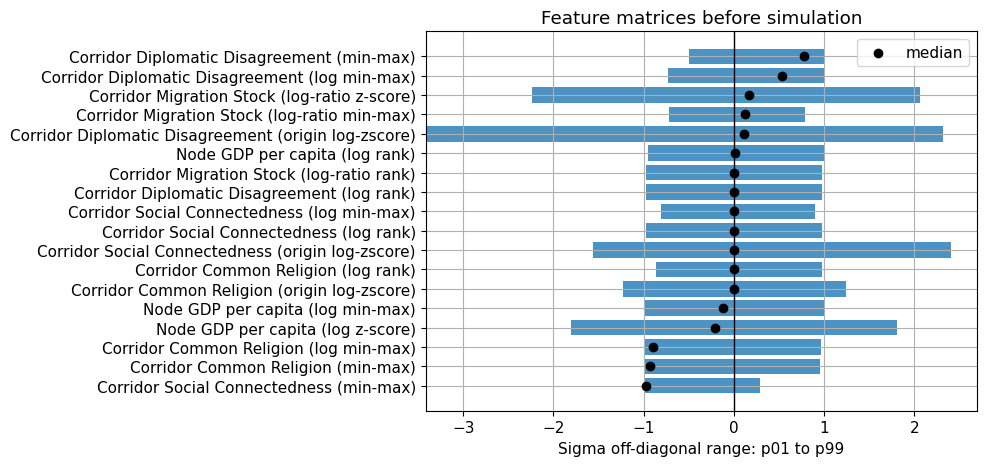

In [256]:
sigma_objects_val = {}
sigma_objects_test = {}
corridor_tables_val = {}
corridor_tables_test = {}
sigma_diag_rows = []

for model_key, spec in MODEL_SPECS.items():
    if spec["kind"] == "gravity_feature":
        Sigma_val, table_val = build_sigma_for_model(model_key, nodes_val, gravity_pairs)
        Sigma_test, table_test = build_sigma_for_model(model_key, nodes_test, gravity_pairs)
        corridor_tables_val[model_key] = table_val
        corridor_tables_test[model_key] = table_test
    else:
        Sigma_val = build_sigma_for_model(model_key, nodes_val, gravity_pairs)
        Sigma_test = build_sigma_for_model(model_key, nodes_test, gravity_pairs)
    sigma_objects_val[model_key] = Sigma_val
    sigma_objects_test[model_key] = Sigma_test

    off = ~np.eye(Sigma_val.shape[0], dtype=bool)
    vals = Sigma_val.to_numpy()[off]
    sigma_diag_rows.append({
        "model": model_key,
        "label": spec["label"],
        "family": spec["family"],
        "min": np.nanmin(vals),
        "p01": np.nanquantile(vals, 0.01),
        "median": np.nanmedian(vals),
        "p99": np.nanquantile(vals, 0.99),
        "max": np.nanmax(vals),
        "share_negative": np.mean(vals < 0),
        "share_positive": np.mean(vals > 0),
        "share_zero": np.mean(np.isclose(vals, 0.0)),
    })

sigma_diag = pd.DataFrame(sigma_diag_rows)
display(sigma_diag)

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = sigma_diag.sort_values("median")
ax.barh(plot_df["label"], plot_df["p99"] - plot_df["p01"], left=plot_df["p01"], alpha=0.8)
ax.scatter(plot_df["median"], plot_df["label"], color="black", zorder=3, label="median")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Sigma off-diagonal range: p01 to p99")
ax.set_title("Feature matrices before simulation")
ax.legend()
plt.tight_layout()
savefig("01_sigma_ranges")
plt.show()

## 5. Calibration Tuning

For each feature, tune only \(\sigma\) on the calibration split. A high selected \(\sigma\) means the feature needs to be diluted toward RM-like behavior; a lower selected \(\sigma\) means the feature is useful while active.

In [257]:
def run_rm(nodes, flows, D):
    return RM(nodes=nodes, flows=flows, distance_matrix=D).run()


def run_ferm(nodes, flows, D, Sigma, sigma, num_particles=NUM_PARTICLES):
    return FERM(nodes=nodes, flows=flows, features=Sigma, distance_matrix=D).run(
        num_particles=num_particles,
        sigma=float(sigma),
        verbose=False,
    )

rm_val = run_rm(nodes_val, flows_val, D_val)
rm_test = run_rm(nodes_test, flows_test, D_test)

calibration_rows = []
calibration_results = {}

for model_key, spec in MODEL_SPECS.items():
    Sigma_val = sigma_objects_val[model_key]
    for sigma in SIGMA_GRID:
        print(f"calibration | {model_key} | sigma={sigma}")
        result = run_ferm(nodes_val, flows_val, D_val, Sigma_val, sigma=sigma, num_particles=NUM_PARTICLES)
        route_df = compare_to_rm(rm_val.comparison, result.comparison, model_key)
        row = summarize_against_observed(result.comparison, label=model_key, family=spec["family"], sigma=sigma)
        row.update(summarize_vs_rm(route_df, model_key))
        row["label"] = spec["label"]
        calibration_rows.append(row)
        calibration_results[(model_key, sigma)] = {"result": result, "routes": route_df}

calibration_df = pd.DataFrame(calibration_rows)
calibration_df = calibration_df.sort_values(
    ["median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(calibration_df)

best_by_model = (
    calibration_df.sort_values(
        ["model", "median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
        ascending=[True, False, False, False, False],
    )
    .groupby("model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_by_model[["model", "label", "family", "sigma", "median_improvement_abs_log", "share_better_abs_log", "Pearson_log", "R2_log", "R2_log_gain_vs_RM", "zero_pred_share"]])

calibration | gdp_ferm | sigma=0.5
calibration | gdp_ferm | sigma=1.0
calibration | gdp_ferm | sigma=2.0
calibration | gdp_ferm | sigma=5.0
calibration | gdp_ferm | sigma=8.0
calibration | gdp_ferm_log_minmax | sigma=0.5
calibration | gdp_ferm_log_minmax | sigma=1.0
calibration | gdp_ferm_log_minmax | sigma=2.0
calibration | gdp_ferm_log_minmax | sigma=5.0
calibration | gdp_ferm_log_minmax | sigma=8.0
calibration | gdp_ferm_log_rank | sigma=0.5
calibration | gdp_ferm_log_rank | sigma=1.0
calibration | gdp_ferm_log_rank | sigma=2.0
calibration | gdp_ferm_log_rank | sigma=5.0
calibration | gdp_ferm_log_rank | sigma=8.0
calibration | abel_option_b | sigma=0.5
calibration | abel_option_b | sigma=1.0
calibration | abel_option_b | sigma=2.0
calibration | abel_option_b | sigma=5.0
calibration | abel_option_b | sigma=8.0
calibration | abel_option_b_log_ratio_minmax | sigma=0.5
calibration | abel_option_b_log_ratio_minmax | sigma=1.0
calibration | abel_option_b_log_ratio_minmax | sigma=2.0
cali

,model,family,sigma,pairs,observed_total,predicted_total,MAE,RMSE,Pearson_log,Spearman_log,...,zero_pred_observed_total,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,R2_log_gain_vs_RM,R2_log_model,R2_log_RM,p10_improvement_abs_log,p90_improvement_abs_log,label
0,gdp_ferm_log_rank,traditional,5.0,2070,5751056.0,5751056.0,3870.163994,15831.076551,0.705334,0.709384,...,95.0,0.056350,0.113888,0.671014,0.299421,-0.236745,-0.536165,-0.231431,0.526257,Node GDP per capita (log rank)
1,gdp_ferm,traditional,8.0,2070,5751056.0,5751056.0,3835.738425,15575.106355,0.709881,0.712703,...,73.0,0.055240,0.121920,0.671981,0.321441,-0.214724,-0.536165,-0.232636,0.563347,Node GDP per capita (log z-score)
2,gdp_ferm,traditional,5.0,2070,5751056.0,5751056.0,3859.294779,15578.822824,0.716024,0.720821,...,237.0,0.050935,0.134201,0.617874,0.356138,-0.180027,-0.536165,-0.414843,0.768739,Node GDP per capita (log z-score)
3,gdp_ferm_log_minmax,traditional,5.0,2070,5751056.0,5751056.0,3835.461302,15650.953573,0.706315,0.709225,...,27.0,0.050076,0.113099,0.677295,0.299091,-0.237074,-0.536165,-0.204094,0.507292,Node GDP per capita (log min-max)
4,rel_scaled_sci_2021,relational,5.0,2070,5751056.0,5751056.0,3848.894033,16200.019584,0.677267,0.674722,...,149.0,0.045577,0.086961,0.712560,0.248111,-0.288054,-0.536165,-0.236170,0.398716,Corridor Social Connectedness (min-max)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,gdp_ferm,traditional,0.5,2070,5751056.0,5751056.0,5187.635484,31991.376145,0.167893,0.137052,...,4922028.0,-0.646189,-0.920934,0.076812,-3.293016,-3.829181,-0.536165,-2.534286,-0.001663,Node GDP per capita (log z-score)
86,abel_option_b,relational,1.0,2070,5751056.0,5751056.0,5057.053203,32267.218624,0.309630,0.334669,...,2467104.0,-0.647701,-0.897875,0.042029,-3.055048,-3.591213,-0.536165,-2.332745,-0.004968,Corridor Migration Stock (log-ratio z-score)
87,rel_comrelig_row_log_zscore,relational,0.5,2070,5751056.0,5751056.0,4955.141982,32562.760298,0.232154,0.167218,...,4029856.0,-0.667526,-0.953952,0.052174,-3.349190,-3.885355,-0.536165,-2.526747,-0.003007,Corridor Common Religion (origin log-zscore)
88,abel_option_b_log_ratio_rank,relational,0.5,2070,5751056.0,5751056.0,5157.008419,33339.419801,0.244409,0.290719,...,3169861.0,-0.691147,-0.957276,0.029952,-3.324132,-3.860298,-0.536165,-2.508413,-0.007359,Corridor Migration Stock (log-ratio rank)


,model,label,family,sigma,median_improvement_abs_log,share_better_abs_log,Pearson_log,R2_log,R2_log_gain_vs_RM,zero_pred_share
0,abel_option_b,Corridor Migration Stock (log-ratio z-score),relational,8.0,-0.001576,0.468599,0.658435,-0.591127,-0.054962,0.015459
1,abel_option_b_log_ratio_minmax,Corridor Migration Stock (log-ratio min-max),relational,8.0,0.002025,0.535749,0.665819,-0.513268,0.022897,0.011111
2,abel_option_b_log_ratio_rank,Corridor Migration Stock (log-ratio rank),relational,8.0,0.002938,0.536715,0.666880,-0.522076,0.014089,0.015459
3,gdp_ferm,Node GDP per capita (log z-score),traditional,8.0,0.055240,0.671981,0.709881,-0.214724,0.321441,0.002899
4,gdp_ferm_log_minmax,Node GDP per capita (log min-max),traditional,5.0,0.050076,0.677295,0.706315,-0.237074,0.299091,0.001449
5,gdp_ferm_log_rank,Node GDP per capita (log rank),traditional,5.0,0.056350,0.671014,0.705334,-0.236745,0.299421,0.003865
6,rel_comrelig,Corridor Common Religion (min-max),relational,8.0,0.023899,0.623671,0.674614,-0.426429,0.109737,0.007246
7,rel_comrelig_log_minmax,Corridor Common Religion (log min-max),relational,8.0,0.021895,0.627536,0.674404,-0.435072,0.101093,0.007729
8,rel_comrelig_log_rank,Corridor Common Religion (log rank),relational,8.0,-0.004190,0.442995,0.662409,-0.592703,-0.056537,0.009662
9,rel_comrelig_row_log_zscore,Corridor Common Religion (origin log-zscore),relational,8.0,-0.021759,0.367633,0.634398,-0.813656,-0.277491,0.031401


saved: outputs/presentation_figures/02_calibration_sigma_tuning.png


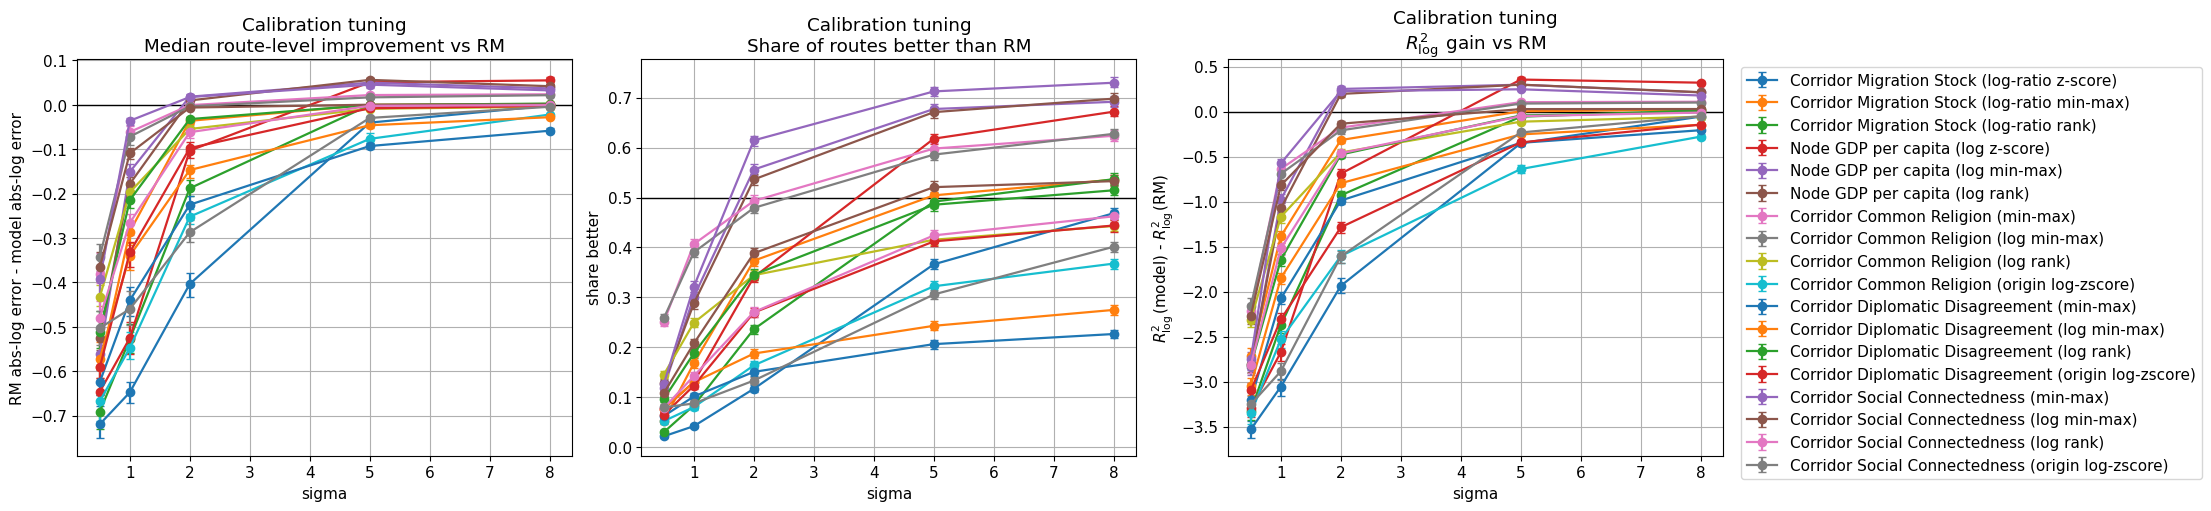

In [258]:
BOOTSTRAP_N = 500
BOOTSTRAP_SEED = 20240609
BOOTSTRAP_INTERVAL = "68% bootstrap interval"


def bootstrap_calibration_intervals(calibration_results, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for (model_key, sigma), payload in calibration_results.items():
        route_df = payload["routes"].dropna(subset=["improvement_abs_log", "num_migrants", "pred_rm", f"pred_{model_key}"]).copy()
        x = route_df["improvement_abs_log"].to_numpy(dtype=float)
        n = len(route_df)
        if n == 0:
            rows.append({
                "model": model_key,
                "sigma": sigma,
                "median_improvement_ci_low": np.nan,
                "median_improvement_ci_high": np.nan,
                "share_better_ci_low": np.nan,
                "share_better_ci_high": np.nan,
                "R2_log_gain_ci_low": np.nan,
                "R2_log_gain_ci_high": np.nan,
            })
            continue

        med_samples = np.empty(n_boot, dtype=float)
        share_samples = np.empty(n_boot, dtype=float)
        r2_gain_samples = np.empty(n_boot, dtype=float)
        for b in range(n_boot):
            sample = route_df.iloc[rng.integers(0, n, size=n)]
            sample_x = sample["improvement_abs_log"].to_numpy(dtype=float)
            med_samples[b] = np.median(sample_x)
            share_samples[b] = np.mean(sample_x > 0)
            r2_gain_samples[b] = route_r2_log_gain_vs_rm(sample, model_key)[0]

        rows.append({
            "model": model_key,
            "sigma": sigma,
            "median_improvement_ci_low": np.quantile(med_samples, 0.16),
            "median_improvement_ci_high": np.quantile(med_samples, 0.84),
            "share_better_ci_low": np.quantile(share_samples, 0.16),
            "share_better_ci_high": np.quantile(share_samples, 0.84),
            "R2_log_gain_ci_low": np.quantile(r2_gain_samples, 0.16),
            "R2_log_gain_ci_high": np.quantile(r2_gain_samples, 0.84),
        })
    return pd.DataFrame(rows)


calibration_ci_df = bootstrap_calibration_intervals(calibration_results)
ci_cols = [
    "median_improvement_ci_low", "median_improvement_ci_high",
    "share_better_ci_low", "share_better_ci_high",
    "R2_log_gain_ci_low", "R2_log_gain_ci_high",
]
calibration_df = (
    calibration_df.drop(columns=ci_cols, errors="ignore")
    .merge(calibration_ci_df, on=["model", "sigma"], how="left")
)


def plot_calibration_curve(ax, g, y_col, low_col, high_col, label):
    g = g.sort_values("sigma")
    x = g["sigma"].to_numpy(dtype=float)
    y = g[y_col].to_numpy(dtype=float)

    if low_col in g.columns and high_col in g.columns and g[[low_col, high_col]].notna().all().all():
        low = g[low_col].to_numpy(dtype=float)
        high = g[high_col].to_numpy(dtype=float)
        yerr = np.vstack([
            np.maximum(y - low, 0),
            np.maximum(high - y, 0),
        ])
        ax.errorbar(x, y, yerr=yerr, marker="o", capsize=3, linewidth=1.6, label=label)
    else:
        ax.plot(x, y, marker="o", label=label)


fig, axes = plt.subplots(1, 3, figsize=(22, 5), constrained_layout=True)

for model_key, g in calibration_df.groupby("model"):
    label = MODEL_SPECS[model_key]["label"]
    plot_calibration_curve(
        axes[0], g,
        "median_improvement_abs_log", "median_improvement_ci_low", "median_improvement_ci_high",
        label,
    )
    plot_calibration_curve(
        axes[1], g,
        "share_better_abs_log", "share_better_ci_low", "share_better_ci_high",
        label,
    )
    plot_calibration_curve(
        axes[2], g,
        "R2_log_gain_vs_RM", "R2_log_gain_ci_low", "R2_log_gain_ci_high",
        label,
    )

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Calibration tuning\nMedian route-level improvement vs RM")
axes[0].set_xlabel("sigma")
axes[0].set_ylabel("RM abs-log error - model abs-log error")

axes[1].axhline(0.5, color="black", linewidth=1)
axes[1].set_title("Calibration tuning\nShare of routes better than RM")
axes[1].set_xlabel("sigma")
axes[1].set_ylabel("share better")

axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Calibration tuning\n$R^2_{\log}$ gain vs RM")
axes[2].set_xlabel("sigma")
axes[2].set_ylabel("$R^2_{\log}$(model) - $R^2_{\log}$(RM)")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

savefig("02_calibration_sigma_tuning")
plt.show()


## 5a. Normalization Sensitivity

This section compares normalization variants within each feature group. It selects one calibration winner per group, so the test section remains a clean comparison across features rather than across every possible scaling.


Selected normalization per feature group


,feature_group_label,model,label,transform,sigma,median_improvement_abs_log,share_better_abs_log,Pearson_log,R2_log,R2_log_gain_vs_RM,zero_pred_share
0,Node GDP per capita,gdp_ferm_log_rank,Node GDP per capita (log rank),log_rank,5.0,0.056350,0.671014,0.705334,-0.236745,0.299421,0.003865
1,Corridor Migration Stock,abel_option_b_log_ratio_rank,Corridor Migration Stock (log-ratio rank),log_ratio_rank,8.0,0.002938,0.536715,0.666880,-0.522076,0.014089,0.015459
2,Corridor Social Connectedness,rel_scaled_sci_2021,Corridor Social Connectedness (min-max),minmax,5.0,0.045577,0.712560,0.677267,-0.288054,0.248111,0.004348
3,Corridor Common Religion,rel_comrelig,Corridor Common Religion (min-max),minmax,8.0,0.023899,0.623671,0.674614,-0.426429,0.109737,0.007246
4,Corridor Diplomatic Disagreement,rel_diplo_disagreement_log_rank,Corridor Diplomatic Disagreement (log rank),log_rank,8.0,0.000431,0.514493,0.654239,-0.539984,-0.003818,0.010145


,feature_group_label,model,label,transform,sigma,median_improvement_abs_log,share_better_abs_log,Pearson_log,R2_log,R2_log_gain_vs_RM,zero_pred_share
65,Corridor Common Religion,rel_comrelig_log_minmax,Corridor Common Religion (log min-max),log_minmax,0.5,-0.341572,0.258454,0.250686,-2.695378,-2.159213,0.414976
46,Corridor Common Religion,rel_comrelig_log_minmax,Corridor Common Religion (log min-max),log_minmax,1.0,-0.071756,0.390338,0.438586,-1.227682,-0.691516,0.235266
28,Corridor Common Religion,rel_comrelig_log_minmax,Corridor Common Religion (log min-max),log_minmax,2.0,-0.003249,0.479227,0.585568,-0.744258,-0.208092,0.084541
13,Corridor Common Religion,rel_comrelig_log_minmax,Corridor Common Religion (log min-max),log_minmax,5.0,0.016911,0.585990,0.668941,-0.446585,0.089581,0.008696
10,Corridor Common Religion,rel_comrelig_log_minmax,Corridor Common Religion (log min-max),log_minmax,8.0,0.021895,0.627536,0.674404,-0.435072,0.101093,0.007729
...,...,...,...,...,...,...,...,...,...,...,...
85,Node GDP per capita,gdp_ferm,Node GDP per capita (log z-score),log_zscore,0.5,-0.646189,0.076812,0.167893,-3.829181,-3.293016,0.852657
77,Node GDP per capita,gdp_ferm,Node GDP per capita (log z-score),log_zscore,1.0,-0.525457,0.130435,0.255547,-3.208749,-2.672584,0.592271
50,Node GDP per capita,gdp_ferm,Node GDP per capita (log z-score),log_zscore,2.0,-0.102963,0.340580,0.572548,-1.225289,-0.689123,0.118841
2,Node GDP per capita,gdp_ferm,Node GDP per capita (log z-score),log_zscore,5.0,0.050935,0.617874,0.716024,-0.180027,0.356138,0.006280


saved: outputs/presentation_figures/02a_normalization_sensitivity_all_features.png


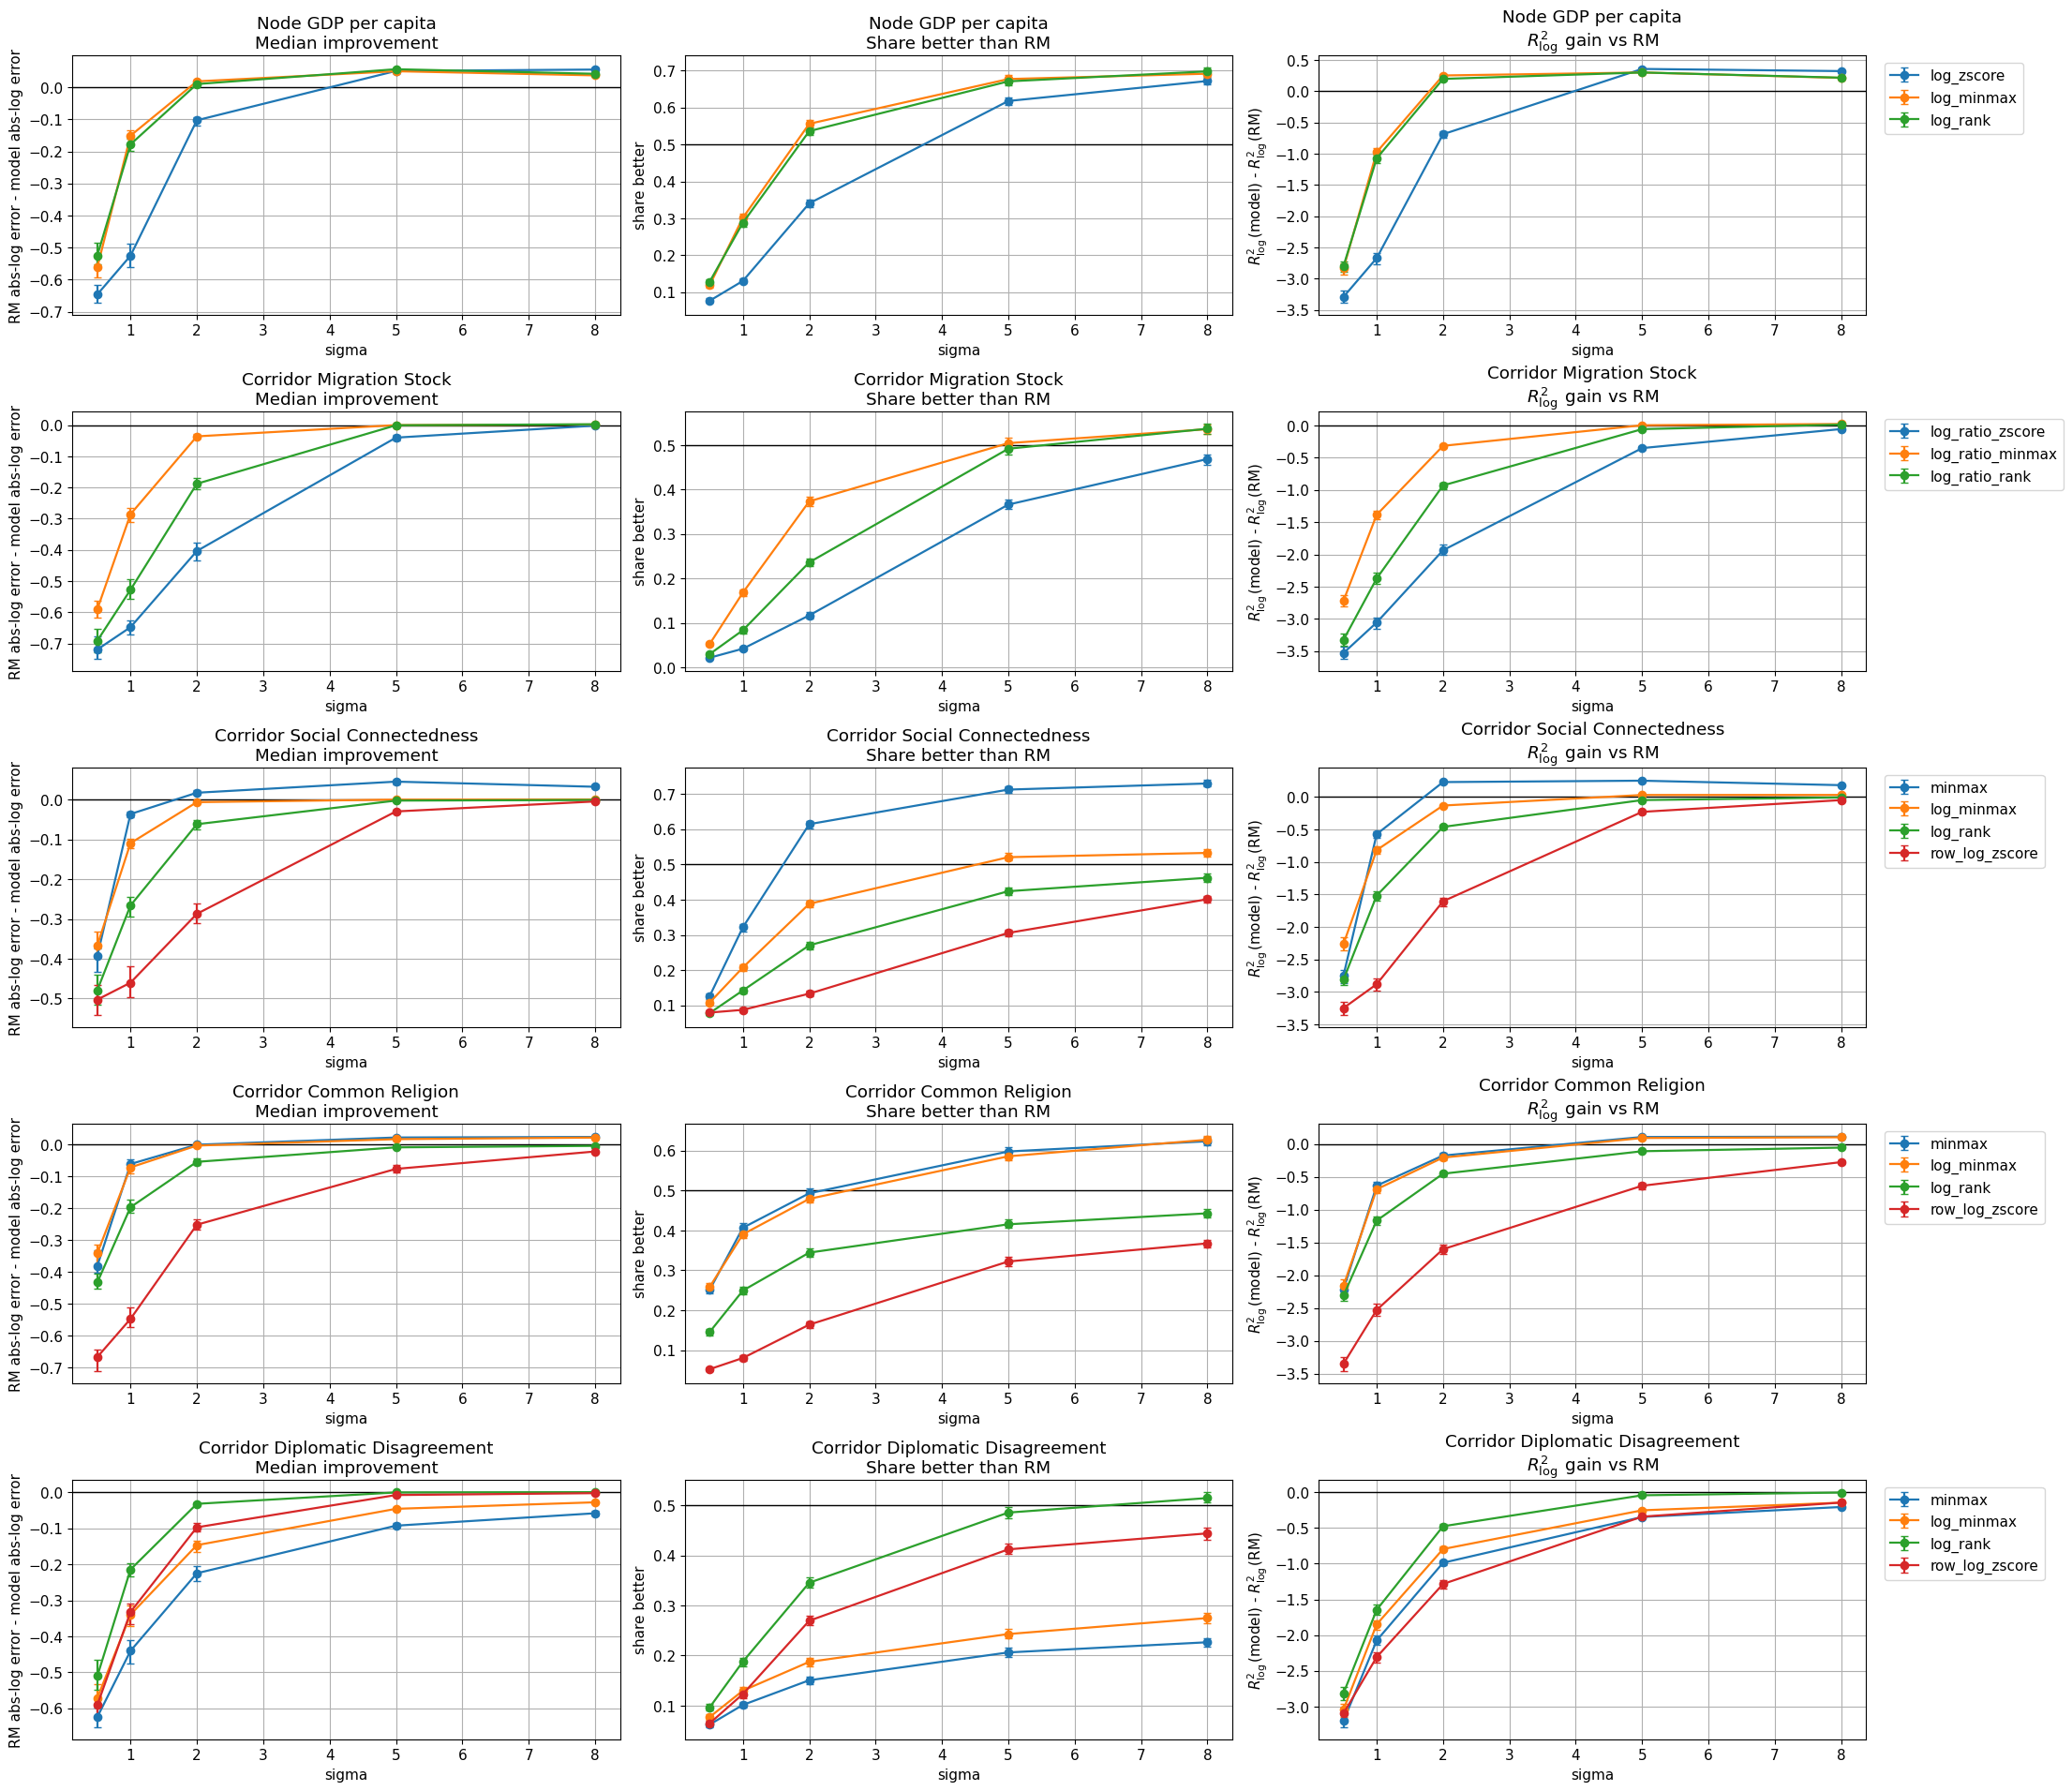

In [259]:
normalization_calibration = calibration_df.copy()
normalization_calibration["feature_group"] = normalization_calibration["model"].map(lambda k: MODEL_SPECS[k].get("feature_group", k))
normalization_calibration["feature_group_label"] = normalization_calibration["feature_group"].map(FEATURE_GROUP_LABELS).fillna(normalization_calibration["feature_group"])
normalization_calibration["transform"] = normalization_calibration["model"].map(lambda k: MODEL_SPECS[k].get("transform", "baseline"))

best_by_feature_group = (
    normalization_calibration.sort_values(
        ["feature_group", "median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM", "Pearson_log"],
        ascending=[True, False, False, False, False],
    )
    .groupby("feature_group", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

ordered_groups = [g for g in FEATURE_GROUP_ORDER if g in set(best_by_feature_group["feature_group"])]
report_best_by_model = pd.concat(
    [best_by_feature_group[best_by_feature_group["feature_group"] == g] for g in ordered_groups],
    ignore_index=True,
)

print("Selected normalization per feature group")
display(report_best_by_model[[
    "feature_group_label", "model", "label", "transform", "sigma",
    "median_improvement_abs_log", "share_better_abs_log", "Pearson_log", "R2_log", "R2_log_gain_vs_RM", "zero_pred_share"
]])

display(normalization_calibration[[
    "feature_group_label", "model", "label", "transform", "sigma",
    "median_improvement_abs_log", "share_better_abs_log", "Pearson_log", "R2_log", "R2_log_gain_vs_RM", "zero_pred_share"
]].sort_values(["feature_group_label", "transform", "sigma"]))

if "plot_calibration_curve" not in globals():
    def plot_calibration_curve(ax, g, y_col, low_col, high_col, label):
        g = g.sort_values("sigma")
        ax.plot(g["sigma"], g[y_col], marker="o", label=label)

from textwrap import fill

n_groups = len(ordered_groups)
fig, axes = plt.subplots(n_groups, 3, figsize=(22, 3.8 * n_groups), squeeze=False, constrained_layout=True)

for row_idx, group in enumerate(ordered_groups):
    sub = normalization_calibration[normalization_calibration["feature_group"] == group].copy()
    group_label = FEATURE_GROUP_LABELS.get(group, group)
    for model_key, g in sub.groupby("model"):
        transform_label = MODEL_SPECS[model_key].get("transform", model_key)
        plot_calibration_curve(
            axes[row_idx, 0], g,
            "median_improvement_abs_log", "median_improvement_ci_low", "median_improvement_ci_high",
            transform_label,
        )
        plot_calibration_curve(
            axes[row_idx, 1], g,
            "share_better_abs_log", "share_better_ci_low", "share_better_ci_high",
            transform_label,
        )
        plot_calibration_curve(
            axes[row_idx, 2], g,
            "R2_log_gain_vs_RM", "R2_log_gain_ci_low", "R2_log_gain_ci_high",
            transform_label,
        )

    wrapped_group_label = fill(group_label, width=42)

    axes[row_idx, 0].axhline(0, color="black", linewidth=1)
    axes[row_idx, 0].set_title(f"{wrapped_group_label}\nMedian improvement")
    axes[row_idx, 0].set_xlabel("sigma")
    axes[row_idx, 0].set_ylabel("RM abs-log error - model abs-log error")

    axes[row_idx, 1].axhline(0.5, color="black", linewidth=1)
    axes[row_idx, 1].set_title(f"{wrapped_group_label}\nShare better than RM")
    axes[row_idx, 1].set_xlabel("sigma")
    axes[row_idx, 1].set_ylabel("share better")
    
    axes[row_idx, 2].axhline(0, color="black", linewidth=1)
    axes[row_idx, 2].set_title(f"{wrapped_group_label}\n$R^2_{{\\log}}$ gain vs RM")
    axes[row_idx, 2].set_xlabel("sigma")
    axes[row_idx, 2].set_ylabel("$R^2_{\\log}$(model) - $R^2_{\\log}$(RM)")
    axes[row_idx, 2].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

savefig("02a_normalization_sensitivity_all_features")
plt.show()


## 6. Test Evaluation

Now freeze each feature group at its calibration-selected normalization and `sigma`, evaluate on `test_2019_h2`, and compare results. The test section therefore reports one GDP, one Abel, one SCI, one common-religion, and one diplomatic-disagreement specification.


In [260]:
test_results = {"rm": {"result": rm_test, "label": "RM", "family": "baseline", "sigma": np.nan}}
test_rows = [summarize_against_observed(rm_test.comparison, label="rm", family="baseline", sigma=np.nan)]
route_results = {}

models_for_test = report_best_by_model if "report_best_by_model" in globals() else best_by_model

for _, best in models_for_test.iterrows():
    model_key = best["model"]
    sigma = float(best["sigma"])
    spec = MODEL_SPECS[model_key]
    print(f"test | {model_key} | sigma={sigma}")
    result = run_ferm(nodes_test, flows_test, D_test, sigma_objects_test[model_key], sigma=sigma, num_particles=NUM_PARTICLES)
    test_results[model_key] = {"result": result, "label": spec["label"], "family": spec["family"], "sigma": sigma}
    row = summarize_against_observed(result.comparison, label=model_key, family=spec["family"], sigma=sigma)
    route_df = compare_to_rm(rm_test.comparison, result.comparison, model_key)
    row.update(summarize_vs_rm(route_df, model_key))
    row["label"] = spec["label"]
    test_rows.append(row)
    route_results[model_key] = route_df

test_summary = pd.DataFrame(test_rows)
test_summary = test_summary.sort_values(["median_improvement_abs_log", "Pearson_log"], ascending=[False, False])
display(test_summary)



test | gdp_ferm_log_rank | sigma=5.0
test | abel_option_b_log_ratio_rank | sigma=8.0
test | rel_scaled_sci_2021 | sigma=5.0
test | rel_comrelig | sigma=8.0
test | rel_diplo_disagreement_log_rank | sigma=8.0


,model,family,sigma,pairs,observed_total,predicted_total,MAE,RMSE,Pearson_log,Spearman_log,...,zero_pred_observed_total,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,R2_log_gain_vs_RM,R2_log_model,R2_log_RM,p10_improvement_abs_log,p90_improvement_abs_log,label
1,gdp_ferm_log_rank,traditional,5.0,2070,6186048.0,6186048.0,4301.993660,17902.175504,0.689029,0.698561,...,125.0,0.057655,0.117112,0.675845,0.298648,-0.258085,-0.556732,-0.230391,0.522931,Node GDP per capita (log rank)
3,rel_scaled_sci_2021,relational,5.0,2070,6186048.0,6186048.0,4287.406485,18168.539458,0.658893,0.661129,...,163.0,0.040731,0.081245,0.708696,0.238802,-0.317930,-0.556732,-0.264889,0.402034,Corridor Social Connectedness (min-max)
4,rel_comrelig,relational,8.0,2070,6186048.0,6186048.0,4381.955172,18712.094158,0.657100,0.662112,...,207.0,0.025108,0.038112,0.630435,0.107467,-0.449265,-0.556732,-0.250160,0.291890,Corridor Common Religion (min-max)
2,abel_option_b_log_ratio_rank,relational,8.0,2070,6186048.0,6186048.0,4420.284261,18963.952320,0.649326,0.654150,...,374.0,0.003204,0.011975,0.542029,0.017392,-0.539340,-0.556732,-0.236138,0.269350,Corridor Migration Stock (log-ratio rank)
5,rel_diplo_disagreement_log_rank,relational,8.0,2070,6186048.0,6186048.0,4452.838907,19824.779586,0.637760,0.648336,...,552.0,0.000057,0.000937,0.502415,-0.003355,-0.560087,-0.556732,-0.198134,0.185788,Corridor Diplomatic Disagreement (log rank)
0,rm,baseline,NaN,2070,6186048.0,6186048.0,4384.796104,18917.088907,0.645768,0.655662,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6a. Permutation Null Test

This is the key test for corridor-specific signal. The shuffled feature keeps the same marginal distribution of \(\Sigma_{ij}\), but assigns values to the wrong OD corridors. If the real feature does not beat this null distribution, the model is not using genuine corridor structure.

Default target: Social Connectedness, because this is the relational feature of primary interest. Add other feature groups to `PERMUTATION_NULL_FEATURE_GROUPS` if needed.


permutation null | rel_scaled_sci_2021 | shuffle=1/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=2/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=3/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=4/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=5/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=6/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=7/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=8/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=9/10 | sigma=5.0
permutation null | rel_scaled_sci_2021 | shuffle=10/10 | sigma=5.0


,model,label,metric,observed,null_mean,null_p05,null_p50,null_p95,z_vs_null,empirical_p_null_ge_observed,n_shuffles
0,rel_scaled_sci_2021,Corridor Social Connectedness (min-max),median_improvement_abs_log,0.040731,0.040674,0.029683,0.036641,0.064536,0.003842,0.454545,10
1,rel_scaled_sci_2021,Corridor Social Connectedness (min-max),share_better_abs_log,0.708696,0.633623,0.603865,0.628986,0.677295,2.665071,0.090909,10
2,rel_scaled_sci_2021,Corridor Social Connectedness (min-max),R2_log_gain_vs_RM,0.238802,0.152851,0.112809,0.151372,0.196365,2.803200,0.090909,10
3,rel_scaled_sci_2021,Corridor Social Connectedness (min-max),Pearson_log,0.658893,0.642650,0.636841,0.641880,0.649195,3.373983,0.090909,10


saved: outputs/presentation_figures/06a_permutation_null_test.png


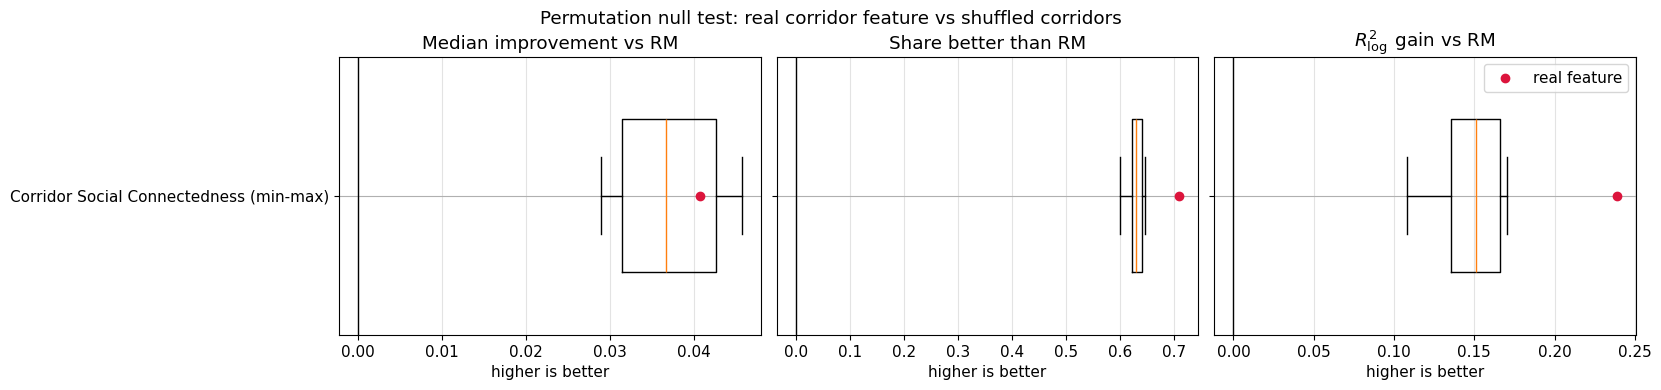

saved: outputs/presentation_figures/06a_permutation_null_summary.csv


In [262]:
PERMUTATION_NULL_FEATURE_GROUPS = ["scaled_sci_2021"]
PERMUTATION_NULL_N = 10 if FAST_MODE else 50
PERMUTATION_NULL_SEED = 20260707
PERMUTATION_NULL_NUM_PARTICLES = NUM_PARTICLES


def shuffle_offdiag_sigma(Sigma: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    """Shuffle off-diagonal Sigma entries, preserving the exact marginal distribution and diagonal."""
    arr = Sigma.to_numpy(dtype=float, copy=True)
    off = ~np.eye(arr.shape[0], dtype=bool)
    values = arr[off].copy()
    rng.shuffle(values)
    arr[off] = values
    return pd.DataFrame(arr, index=Sigma.index, columns=Sigma.columns)


def permutation_target_models(models_df: pd.DataFrame) -> pd.DataFrame:
    targets = models_df.copy()
    targets["feature_group"] = targets["model"].map(lambda k: MODEL_SPECS[k].get("feature_group"))
    targets["kind"] = targets["model"].map(lambda k: MODEL_SPECS[k].get("kind"))
    targets = targets[
        targets["kind"].isin(["gravity_feature", "abel"])
        & targets["feature_group"].isin(PERMUTATION_NULL_FEATURE_GROUPS)
    ].copy()
    return targets.reset_index(drop=True)


def summarize_existing_test_model(model_key: str, sigma: float) -> dict:
    spec = MODEL_SPECS[model_key]
    row = summarize_against_observed(
        test_results[model_key]["result"].comparison,
        label=model_key,
        family=spec["family"],
        sigma=sigma,
    )
    row.update(summarize_vs_rm(route_results[model_key], model_key))
    row["label"] = spec["label"]
    return row


null_targets = permutation_target_models(models_for_test)
if null_targets.empty:
    raise ValueError(
        "No permutation-null targets found. Check PERMUTATION_NULL_FEATURE_GROUPS "
        "and make sure the corresponding feature group is selected for test."
    )

rng = np.random.default_rng(PERMUTATION_NULL_SEED)
permutation_null_rows = []
permutation_observed_rows = []

for _, selected in null_targets.iterrows():
    model_key = selected["model"]
    sigma = float(selected["sigma"])
    spec = MODEL_SPECS[model_key]
    Sigma_test_real = sigma_objects_test[model_key]

    observed_row = summarize_existing_test_model(model_key, sigma)
    observed_row["source_model"] = model_key
    observed_row["source_label"] = spec["label"]
    observed_row["null_type"] = "real feature"
    observed_row["shuffle_id"] = -1
    permutation_observed_rows.append(observed_row)

    for shuffle_id in range(PERMUTATION_NULL_N):
        null_key = f"{model_key}__shuffled_{shuffle_id:03d}"
        Sigma_null = shuffle_offdiag_sigma(Sigma_test_real, rng)
        print(f"permutation null | {model_key} | shuffle={shuffle_id + 1}/{PERMUTATION_NULL_N} | sigma={sigma}")
        result_null = run_ferm(
            nodes_test,
            flows_test,
            D_test,
            Sigma_null,
            sigma=sigma,
            num_particles=PERMUTATION_NULL_NUM_PARTICLES,
        )
        route_null = compare_to_rm(rm_test.comparison, result_null.comparison, null_key)
        row = summarize_against_observed(result_null.comparison, label=null_key, family="permutation_null", sigma=sigma)
        row.update(summarize_vs_rm(route_null, null_key))
        row["source_model"] = model_key
        row["source_label"] = spec["label"]
        row["null_type"] = "shuffled off-diagonal Sigma"
        row["shuffle_id"] = shuffle_id
        permutation_null_rows.append(row)

permutation_null_df = pd.DataFrame(permutation_null_rows)
permutation_observed_df = pd.DataFrame(permutation_observed_rows)

higher_is_better_metrics = [
    "median_improvement_abs_log",
    "share_better_abs_log",
    "R2_log_gain_vs_RM",
    "Pearson_log",
]

permutation_null_summary_rows = []
for _, obs in permutation_observed_df.iterrows():
    model_key = obs["source_model"]
    null_sub = permutation_null_df[permutation_null_df["source_model"] == model_key]
    for metric in higher_is_better_metrics:
        null_values = null_sub[metric].dropna().to_numpy(dtype=float)
        obs_value = float(obs[metric])
        p_empirical = (1 + np.sum(null_values >= obs_value)) / (len(null_values) + 1)
        std = np.std(null_values, ddof=1) if len(null_values) > 1 else np.nan
        z_vs_null = (obs_value - np.mean(null_values)) / std if std and np.isfinite(std) and std > 0 else np.nan
        permutation_null_summary_rows.append({
            "model": model_key,
            "label": obs["source_label"],
            "metric": metric,
            "observed": obs_value,
            "null_mean": np.mean(null_values),
            "null_p05": np.quantile(null_values, 0.05),
            "null_p50": np.quantile(null_values, 0.50),
            "null_p95": np.quantile(null_values, 0.95),
            "z_vs_null": z_vs_null,
            "empirical_p_null_ge_observed": p_empirical,
            "n_shuffles": len(null_values),
        })

permutation_null_summary = pd.DataFrame(permutation_null_summary_rows)
display(permutation_null_summary)

metric_labels = {
    "median_improvement_abs_log": "Median improvement vs RM",
    "share_better_abs_log": "Share better than RM",
    "R2_log_gain_vs_RM": "$R^2_{\\log}$ gain vs RM",
}
plot_metrics = list(metric_labels)
labels = permutation_observed_df["source_label"].tolist()

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5.5 * len(plot_metrics), max(3.6, 0.8 * len(labels) + 1.8)), constrained_layout=True)
if len(plot_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, plot_metrics):
    data = [
        permutation_null_df.loc[permutation_null_df["source_model"] == model_key, metric].dropna().to_numpy(dtype=float)
        for model_key in permutation_observed_df["source_model"]
    ]
    y = np.arange(1, len(labels) + 1)
    ax.boxplot(data, vert=False, positions=y, widths=0.55, showfliers=False)
    obs_values = permutation_observed_df[metric].to_numpy(dtype=float)
    ax.scatter(obs_values, y, color="crimson", zorder=3, label="real feature")
    ax.axvline(0.0, color="black", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(labels if ax is axes[0] else [])
    ax.set_title(metric_labels[metric])
    ax.set_xlabel("higher is better")
    ax.grid(True, axis="x", alpha=0.35)

axes[-1].legend(loc="best")
fig.suptitle("Permutation null test: real corridor feature vs shuffled corridors", y=1.04)
savefig("06a_permutation_null_test")
plt.show()

if SAVE_FIGURES:
    permutation_null_df.to_csv(FIG_DIR / "06a_permutation_null_rows.csv", index=False)
    permutation_observed_df.to_csv(FIG_DIR / "06a_permutation_null_observed.csv", index=False)
    permutation_null_summary.to_csv(FIG_DIR / "06a_permutation_null_summary.csv", index=False)
    print(f"saved: {FIG_DIR / '06a_permutation_null_summary.csv'}")



## 6b. Save Simulation Artifacts

This cell freezes the simulation outputs into tidy files. The graph-only notebook should read these files instead of rerunning the models.


In [261]:
# Save simulation artifacts for graph-only notebooks.
# Run this cell after calibration and test evaluation have completed.
import json
from datetime import datetime

ARTIFACT_DIR = Path("outputs/simulation_artifacts/presentation_all_features")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def _json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.ndarray,)):
        return value.tolist()
    if isinstance(value, (Path,)):
        return str(value)
    return value


def _attach_distance_columns(df: pd.DataFrame, D: pd.DataFrame | None) -> pd.DataFrame:
    out = df.copy()
    if D is None or "distance_km" in out.columns:
        return out
    def _distance(row):
        try:
            return float(D.loc[row["country_from"], row["country_to"]])
        except Exception:
            return np.nan
    out["distance_km"] = out.apply(_distance, axis=1)
    out["log10_distance"] = np.log10(out["distance_km"].where(out["distance_km"] > 0))
    return out


def _route_exports_from_results(results_dict: dict, split_name: str, D: pd.DataFrame | None) -> pd.DataFrame:
    frames = []
    for key, payload in results_dict.items():
        if isinstance(key, tuple):
            model_key, sigma = key
            route_df = payload.get("routes")
            spec = MODEL_SPECS.get(model_key, {})
        else:
            model_key = key
            if model_key == "rm":
                continue
            sigma = payload.get("sigma", np.nan) if isinstance(payload, dict) else np.nan
            route_df = route_results.get(model_key) if "route_results" in globals() else None
            spec = MODEL_SPECS.get(model_key, {})
        if route_df is None:
            continue
        out = _attach_distance_columns(route_df, D)
        out.insert(0, "split", split_name)
        out.insert(1, "model_key", model_key)
        out.insert(2, "model_label", spec.get("label", model_key))
        out.insert(3, "family", spec.get("family", "unknown"))
        out.insert(4, "feature_group", spec.get("feature_group", spec.get("kind", "unknown")))
        out.insert(5, "transform", spec.get("transform", spec.get("mode", "")))
        out.insert(6, "sigma", sigma)
        frames.append(out)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


calibration_df.to_csv(ARTIFACT_DIR / "calibration_summary.csv", index=False)
best_by_model.to_csv(ARTIFACT_DIR / "best_by_model.csv", index=False)
test_summary.to_csv(ARTIFACT_DIR / "test_summary.csv", index=False)

calibration_routes_export = _route_exports_from_results(calibration_results, "calibration", D_val)
test_routes_export = _route_exports_from_results(test_results, "test", D_test)
calibration_routes_export.to_csv(ARTIFACT_DIR / "calibration_routes.csv.gz", index=False, compression="gzip")
test_routes_export.to_csv(ARTIFACT_DIR / "test_routes.csv.gz", index=False, compression="gzip")

prepare_comp(rm_val.comparison).to_csv(ARTIFACT_DIR / "rm_calibration_comparison.csv", index=False)
prepare_comp(rm_test.comparison).to_csv(ARTIFACT_DIR / "rm_test_comparison.csv", index=False)

sigma_diagnostics_export = sigma_diagnostics.copy() if "sigma_diagnostics" in globals() else pd.DataFrame()
if len(sigma_diagnostics_export):
    sigma_diagnostics_export.to_csv(ARTIFACT_DIR / "sigma_diagnostics.csv", index=False)

metadata = {
    "artifact_name": "presentation_all_features",
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "target_continent": TARGET_CONTINENT,
    "calibration_label": CALIBRATION_LABEL,
    "test_label": TEST_LABEL,
    "relational_feature_year": RELATIONAL_FEATURE_YEAR,
    "distance_col": DISTANCE_COL,
    "num_particles": int(NUM_PARTICLES),
    "sigma_grid": [float(x) for x in SIGMA_GRID],
    "model_specs": MODEL_SPECS,
}
for optional_name in ["GDP_TRANSFORM", "SCI_COL", "GDP_COL"]:
    if optional_name in globals():
        metadata[optional_name.lower()] = globals()[optional_name]

with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=_json_safe)

print(f"Saved simulation artifacts to {ARTIFACT_DIR.resolve()}")
print(f"- calibration_summary.csv: {len(calibration_df)} rows")
print(f"- calibration_routes.csv.gz: {len(calibration_routes_export)} rows")
print(f"- test_summary.csv: {len(test_summary)} rows")
print(f"- test_routes.csv.gz: {len(test_routes_export)} rows")


Saved simulation artifacts to /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/simulation_artifacts/presentation_all_features
- calibration_summary.csv: 90 rows
- calibration_routes.csv.gz: 186300 rows
- test_summary.csv: 6 rows
- test_routes.csv.gz: 10350 rows


saved: outputs/presentation_figures/03_test_summary_bars.png


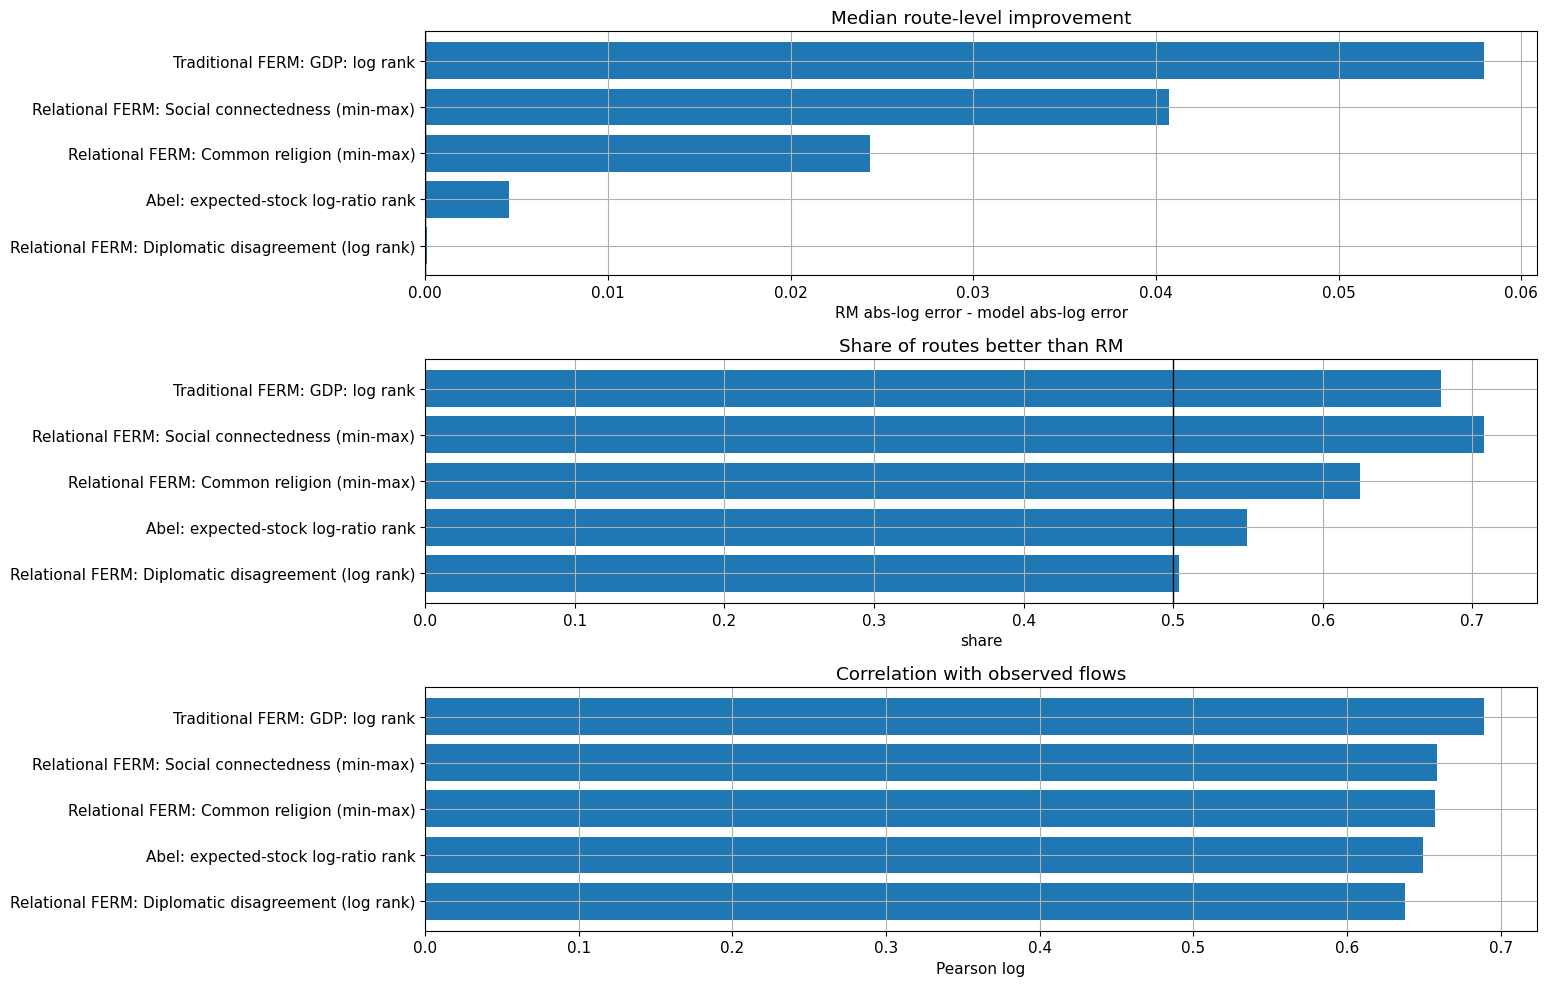

In [216]:
plot_df = test_summary[test_summary["model"] != "rm"].copy()
plot_df = plot_df.sort_values("median_improvement_abs_log")

fig, axes = plt.subplots(3, 1, figsize=(5.2*3, 10))
axes[0].barh(plot_df["label"], plot_df["median_improvement_abs_log"])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Median route-level improvement")
axes[0].set_xlabel("RM abs-log error - model abs-log error")

axes[1].barh(plot_df["label"], plot_df["share_better_abs_log"])
axes[1].axvline(0.5, color="black", linewidth=1)
axes[1].set_title("Share of routes better than RM")
axes[1].set_xlabel("share")

axes[2].barh(plot_df["label"], plot_df["Pearson_log"])
axes[2].set_title("Correlation with observed flows")
axes[2].set_xlabel("Pearson log")

plt.tight_layout()
savefig("03_test_summary_bars")
plt.show()

## 7. Prediction Structure

These plots show whether a feature is adding a small correction to RM, strongly reshuffling predictions, or collapsing routes to zero.

saved: outputs/presentation_figures/04_prediction_structure_vs_rm.png


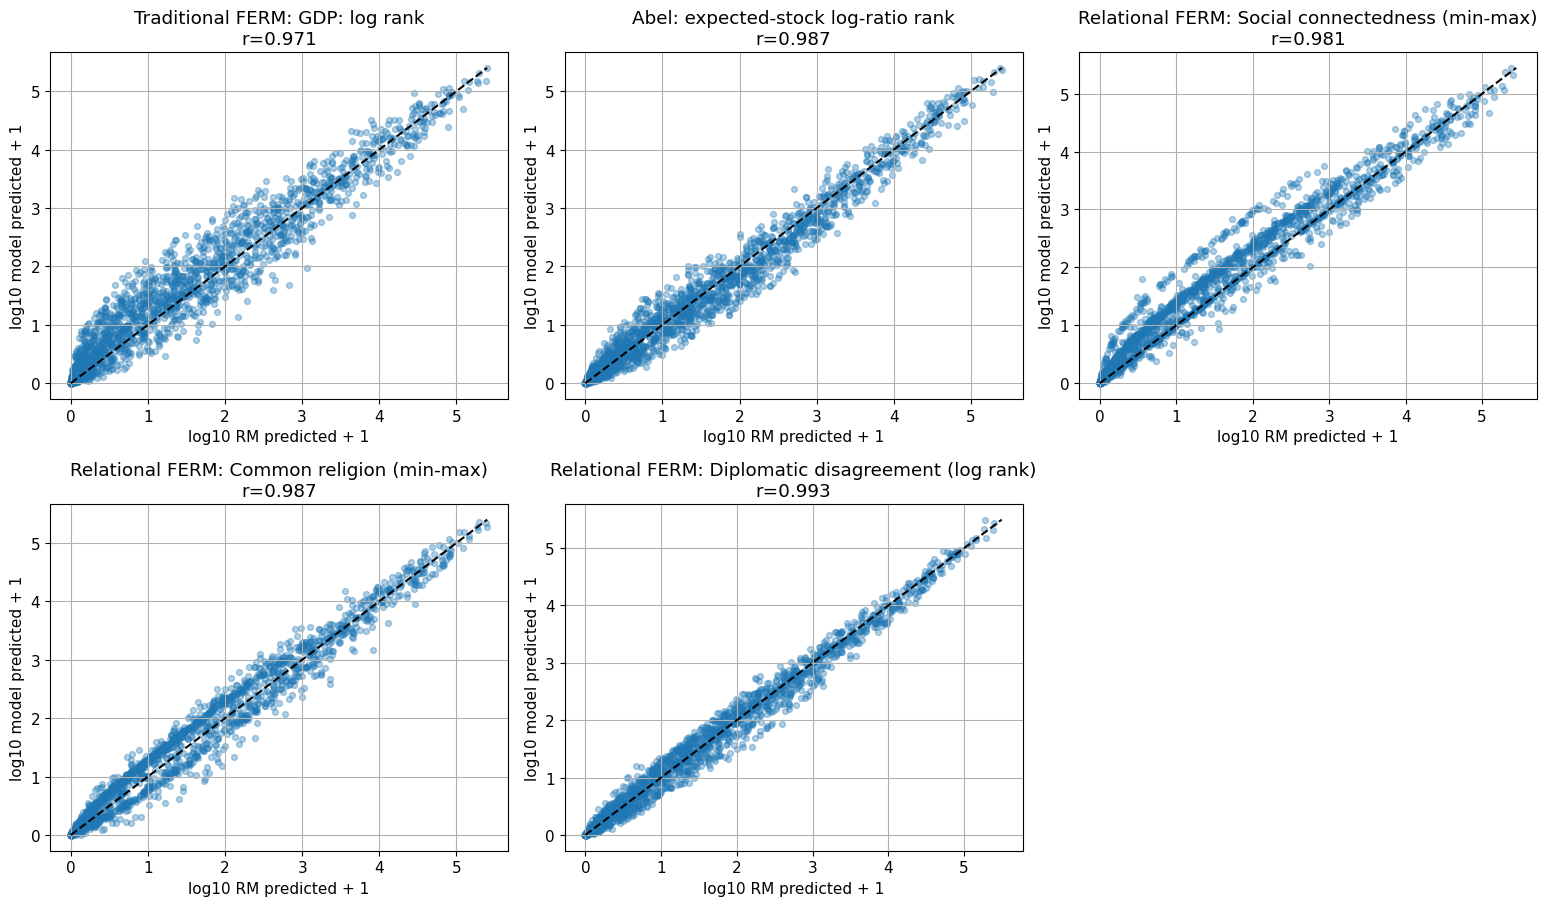

In [217]:
def model_prediction_panel(model_keys=None):
    if model_keys is None:
        model_keys = list(route_results.keys())
    n = len(model_keys)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows), squeeze=False)
    for ax, model_key in zip(axes.flat, model_keys):
        comp = prepare_comp(test_results[model_key]["result"].comparison)
        rm = prepare_comp(rm_test.comparison)
        merged = rm[["country_from", "country_to", "predicted_migrants"]].rename(columns={"predicted_migrants": "pred_rm"}).merge(
            comp[["country_from", "country_to", "predicted_migrants"]].rename(columns={"predicted_migrants": "pred_model"}),
            on=["country_from", "country_to"], how="inner",
        )
        x = log10p(merged["pred_rm"])
        y = log10p(merged["pred_model"])
        r = pd.Series(x).corr(pd.Series(y))
        ax.scatter(x, y, alpha=0.35, s=18)
        lim = max(x.max(), y.max())
        ax.plot([0, lim], [0, lim], linestyle="--", color="black")
        ax.set_title(f"{MODEL_SPECS[model_key]['label']}\nr={r:.3f}")
        ax.set_xlabel("log10 RM predicted + 1")
        ax.set_ylabel("log10 model predicted + 1")
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout()
    savefig("04_prediction_structure_vs_rm")
    plt.show()

model_prediction_panel()

saved: outputs/presentation_figures/05_route_error_scatter.png


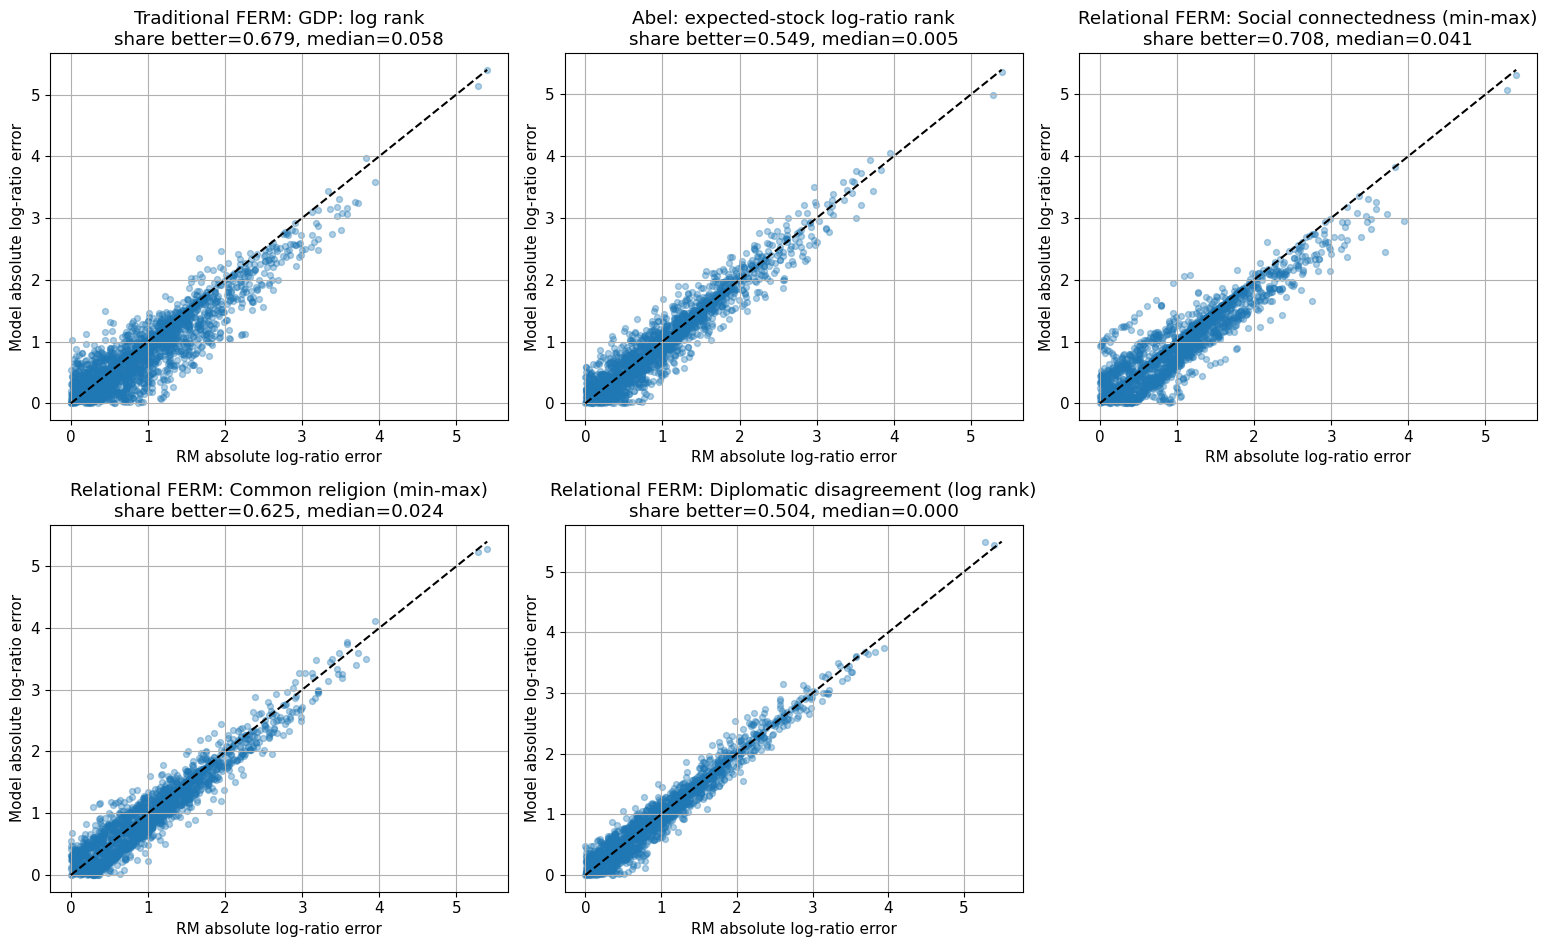

In [218]:
def route_error_panel(model_keys=None):
    if model_keys is None:
        model_keys = list(route_results.keys())
    n = len(model_keys)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), squeeze=False)
    for ax, model_key in zip(axes.flat, model_keys):
        r = route_results[model_key]
        ycol = f"abs_log_{model_key}"
        ax.scatter(r["abs_log_rm"], r[ycol], alpha=0.35, s=18)
        lim = max(r["abs_log_rm"].max(), r[ycol].max())
        ax.plot([0, lim], [0, lim], linestyle="--", color="black")
        ax.set_title(
            f"{MODEL_SPECS[model_key]['label']}\n"
            f"share better={(r['improvement_abs_log'] > 0).mean():.3f}, "
            f"median={r['improvement_abs_log'].median():.3f}"
        )
        ax.set_xlabel("RM absolute log-ratio error")
        ax.set_ylabel("Model absolute log-ratio error")
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout()
    savefig("05_route_error_scatter")
    plt.show()

route_error_panel()

## 8. Error Distributions and Prediction Shifts

CDFs summarize the full error distribution. Shift histograms show how much each feature changes RM predictions.

saved: outputs/presentation_figures/06_error_cdf_and_shifts.png


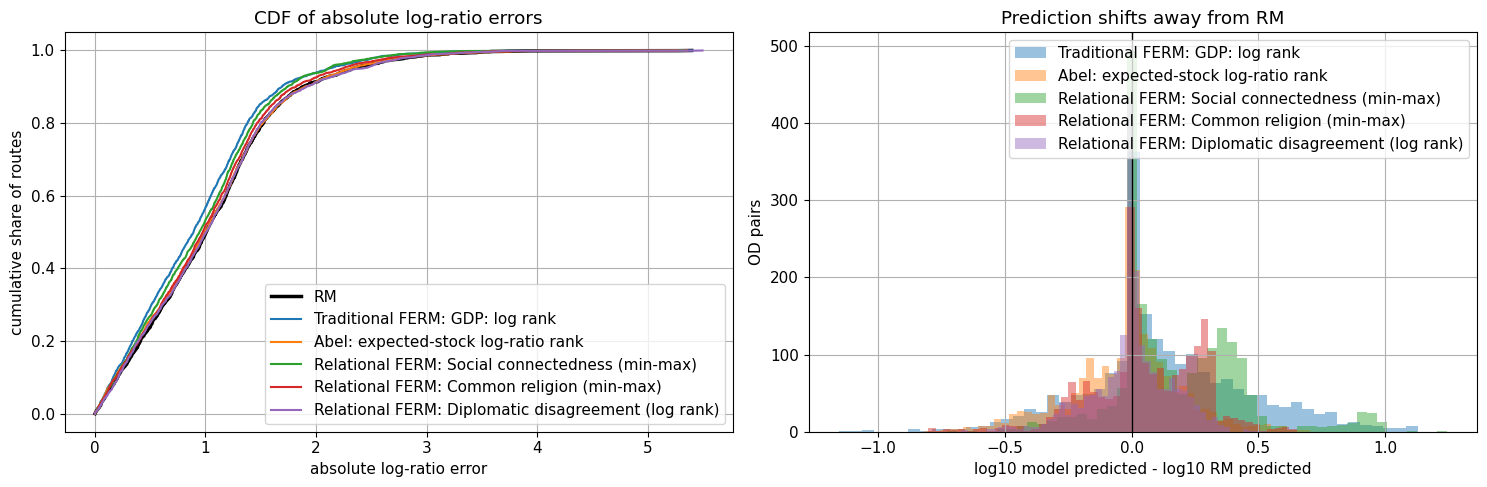

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rm_comp = prepare_comp(rm_test.comparison)
rm_abs = np.sort(rm_comp["abs_log_ratio"].values)
y = np.arange(1, len(rm_abs) + 1) / len(rm_abs)
axes[0].plot(rm_abs, y, label="RM", linewidth=2.5, color="black")

for model_key, info in test_results.items():
    if model_key == "rm":
        continue
    comp = prepare_comp(info["result"].comparison)
    vals = np.sort(comp["abs_log_ratio"].values)
    yy = np.arange(1, len(vals) + 1) / len(vals)
    axes[0].plot(vals, yy, label=info["label"])

axes[0].set_title("CDF of absolute log-ratio errors")
axes[0].set_xlabel("absolute log-ratio error")
axes[0].set_ylabel("cumulative share of routes")
axes[0].legend()

for model_key, r in route_results.items():
    axes[1].hist(r["log_shift_vs_rm"], bins=50, alpha=0.45, label=MODEL_SPECS[model_key]["label"])
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Prediction shifts away from RM")
axes[1].set_xlabel("log10 model predicted - log10 RM predicted")
axes[1].set_ylabel("OD pairs")
axes[1].legend()

plt.tight_layout()
savefig("06_error_cdf_and_shifts")
plt.show()

## 9. Where Each Feature Works

The goal here is not just to say which model wins globally. We want to understand **where** each feature helps: small vs large flows, short vs long corridors, and which routes each feature improves or damages.

,model,label,bin_type,bin,bin_order,median_improvement_abs_log,mean_improvement_abs_log,count
0,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,observed_bin,"(-0.001, 1.38]",0,0.008572,0.035914,551.0
1,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,observed_bin,"(1.38, 1.778]",1,0.045407,0.093544,486.0
2,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,observed_bin,"(1.778, 2.75]",2,0.142647,0.172737,515.0
3,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,observed_bin,"(2.75, 5.343]",3,0.165355,0.170660,518.0
4,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,distance_bin,"(66.999, 2109.0]",0,0.023000,0.034808,520.0
5,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,distance_bin,"(2109.0, 3807.0]",1,0.045987,0.099268,516.0
6,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,distance_bin,"(3807.0, 6021.75]",2,0.066894,0.140299,516.0
7,gdp_ferm_log_rank,Traditional FERM: GDP: log rank,distance_bin,"(6021.75, 11185.0]",3,0.115958,0.194780,518.0
8,abel_option_b_log_ratio_rank,Abel: expected-stock log-ratio rank,observed_bin,"(-0.001, 1.38]",0,0.005839,0.034257,551.0
9,abel_option_b_log_ratio_rank,Abel: expected-stock log-ratio rank,observed_bin,"(1.38, 1.778]",1,0.014144,0.036464,486.0


saved: outputs/presentation_figures/07_where_features_work_bins.png


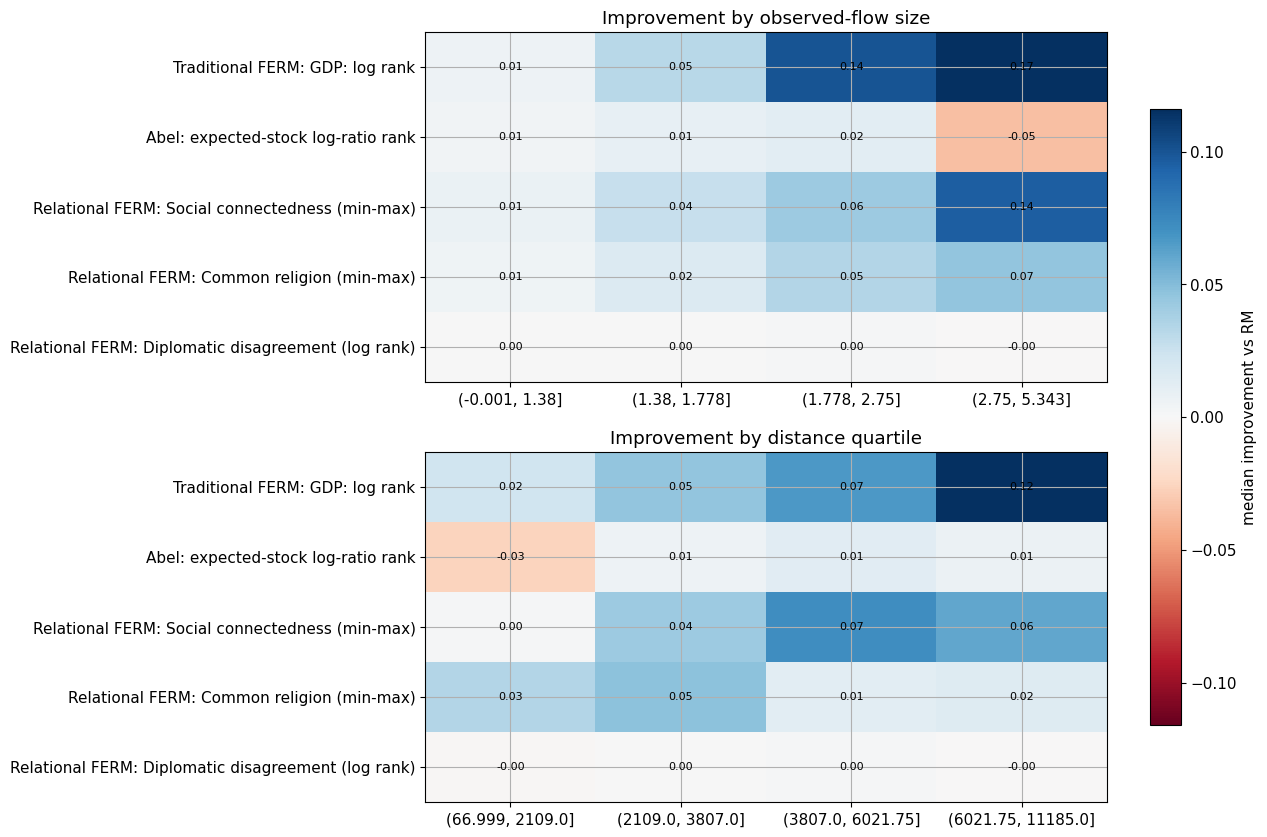

In [220]:
def attach_distance(route_df: pd.DataFrame, D: pd.DataFrame) -> pd.DataFrame:
    out = route_df.copy()
    out["distance"] = [
        D.loc[o, d] if o in D.index and d in D.columns else np.nan
        for o, d in zip(out["country_from"], out["country_to"])
    ]
    return out

binned_rows = []
for model_key, r in route_results.items():
    tmp = attach_distance(r, D_test)
    tmp["observed_bin"] = pd.qcut(log10p(tmp["num_migrants"]), q=4, duplicates="drop")
    tmp["distance_bin"] = pd.qcut(tmp["distance"], q=4, duplicates="drop")
    for bin_col in ["observed_bin", "distance_bin"]:
        grouped = tmp.groupby(bin_col, observed=True)["improvement_abs_log"].agg(["median", "mean", "count"])
        for bin_order, (idx, row) in enumerate(grouped.iterrows()):
            binned_rows.append({
                "model": model_key,
                "label": MODEL_SPECS[model_key]["label"],
                "bin_type": bin_col,
                "bin": str(idx),
                "bin_order": bin_order,
                "median_improvement_abs_log": row["median"],
                "mean_improvement_abs_log": row["mean"],
                "count": row["count"],
            })

binned_df = pd.DataFrame(binned_rows)
display(binned_df)

model_order = [MODEL_SPECS[k]["label"] for k in route_results.keys()]

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
for ax, bin_type, title in [
    (axes[0], "observed_bin", "Improvement by observed-flow size"),
    (axes[1], "distance_bin", "Improvement by distance quartile"),
]:
    sub = binned_df[binned_df["bin_type"] == bin_type].copy()
    bin_order = (
        sub[["bin", "bin_order"]]
        .drop_duplicates()
        .sort_values("bin_order")["bin"]
        .tolist()
    )
    row_order = [label for label in model_order if label in set(sub["label"])]
    pivot = sub.pivot(index="label", columns="bin", values="median_improvement_abs_log")
    pivot = pivot.reindex(index=row_order, columns=bin_order)
    vmax = np.nanmax(np.abs(pivot.values))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=0, ha="center")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="median improvement vs RM")
savefig("07_where_features_work_bins")
plt.show()


,best_label,routes,observed_total,median_observed,route_share
0,Traditional FERM: GDP: log rank,743,2098131.0,64.0,0.358937
1,Relational FERM: Social connectedness (min-max),589,2445172.0,53.0,0.284541
2,Abel: expected-stock log-ratio rank,254,580590.0,47.5,0.122705
3,Relational FERM: Common religion (min-max),227,497317.0,42.0,0.109662
4,Relational FERM: Diplomatic disagreement (log ...,170,451507.0,145.5,0.082126
5,RM,87,113331.0,99.0,0.042029


saved: outputs/presentation_figures/08_route_winners.png


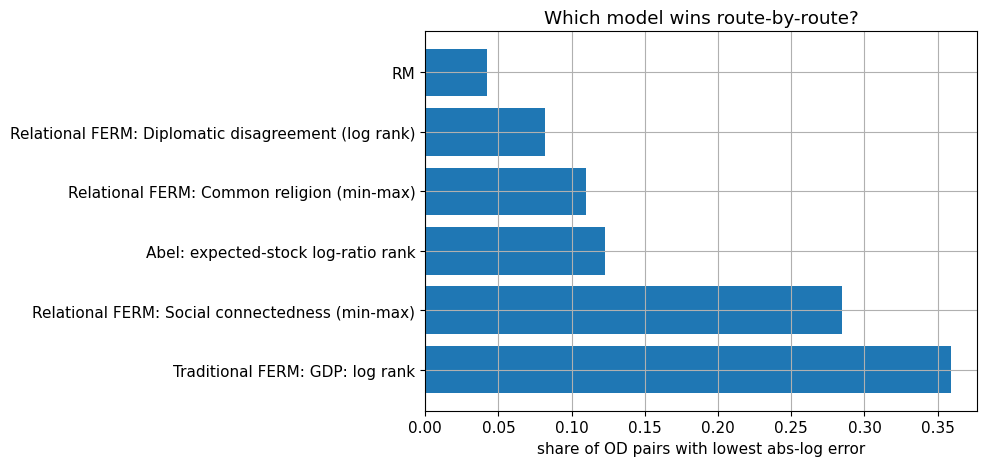

In [221]:
# Winner analysis: for each route, which model has the lowest abs-log error?
base = prepare_comp(rm_test.comparison)[["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants", "abs_log_ratio"]].rename(columns={"abs_log_ratio": "rm"})
error_frames = [base]
for model_key, info in test_results.items():
    if model_key == "rm":
        continue
    comp = prepare_comp(info["result"].comparison)[["country_from", "country_to", "abs_log_ratio"]].rename(columns={"abs_log_ratio": model_key})
    error_frames.append(comp)

error_panel = reduce(lambda left, right: left.merge(right, on=["country_from", "country_to"], how="inner"), error_frames)
error_cols = ["rm"] + [k for k in test_results if k != "rm"]
error_panel["best_model"] = error_panel[error_cols].idxmin(axis=1)
error_panel["best_label"] = error_panel["best_model"].map(lambda k: "RM" if k == "rm" else MODEL_SPECS[k]["label"])

winner_summary = (
    error_panel.groupby("best_label")
    .agg(routes=("best_label", "size"), observed_total=("num_migrants", "sum"), median_observed=("num_migrants", "median"))
    .sort_values("routes", ascending=False)
    .reset_index()
)
winner_summary["route_share"] = winner_summary["routes"] / len(error_panel)
display(winner_summary)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(winner_summary["best_label"], winner_summary["route_share"])
ax.set_title("Which model wins route-by-route?")
ax.set_xlabel("share of OD pairs with lowest abs-log error")
plt.tight_layout()
savefig("08_route_winners")
plt.show()

## 10. Top Route-Level Gains and Losses

These tables are useful for the presentation because they make the abstract metrics concrete.

In [222]:
for model_key, r in route_results.items():
    label = MODEL_SPECS[model_key]["label"]
    print("\n" + "=" * 100)
    print(label)
    show_cols = [
        "country_from_name", "country_to_name", "num_migrants", "pred_rm", f"pred_{model_key}",
        "abs_log_rm", f"abs_log_{model_key}", "improvement_abs_log", "log_shift_vs_rm",
    ]
    print("Top improvements vs RM")
    display(r.sort_values("improvement_abs_log", ascending=False)[show_cols].head(10))
    print("Top deteriorations vs RM")
    display(r.sort_values("improvement_abs_log", ascending=True)[show_cols].head(10))


Traditional FERM: GDP: log rank
Top improvements vs RM


,country_from_name,country_to_name,num_migrants,pred_rm,pred_gdp_ferm_log_rank,abs_log_rm,abs_log_gdp_ferm_log_rank,improvement_abs_log,log_shift_vs_rm
1591,Singapore,Japan,1664.0,8.222116,123.019014,2.256584,1.127926,1.128658,1.128658
54,United Arab Emirates,Hong Kong S.A.R.,211.0,3.664719,61.303570,1.657510,0.531823,1.125687,1.125687
1595,Singapore,South Korea,894.0,4.515855,69.819251,2.210210,1.101672,1.108538,1.108538
79,United Arab Emirates,Singapore,632.0,2.785014,47.463006,2.223336,1.115993,1.107343,1.107343
752,Japan,Qatar,101.0,5.910034,85.158959,1.169120,0.073300,1.095820,1.095820
721,Japan,United Arab Emirates,355.0,21.609353,280.327184,1.197162,0.102238,1.094924,1.094924
1564,Saudi Arabia,Singapore,396.0,22.066004,282.336224,1.235818,0.146488,1.089330,1.089330
64,United Arab Emirates,South Korea,449.0,20.021962,245.281795,1.330539,0.261780,1.068759,1.068759
1540,Saudi Arabia,Hong Kong S.A.R.,428.0,29.036007,345.299701,1.154815,0.093005,1.061810,1.061810
1501,Qatar,Japan,81.0,4.009185,53.275893,1.214047,0.179207,1.034840,1.034840


Top deteriorations vs RM


,country_from_name,country_to_name,num_migrants,pred_rm,pred_gdp_ferm_log_rank,abs_log_rm,abs_log_gdp_ferm_log_rank,improvement_abs_log,log_shift_vs_rm
58,United Arab Emirates,Israel,46.0,129.907798,1462.913826,0.444868,1.493418,-1.048550,1.048550
1499,Qatar,Israel,16.0,15.449027,179.110885,0.014309,1.025091,-1.010782,1.039400
1546,Saudi Arabia,Japan,211.0,337.375516,2850.013451,0.203063,1.128663,-0.925600,0.925600
1550,Saudi Arabia,South Korea,186.0,158.685793,1418.343924,0.068575,0.880246,-0.811671,0.948821
1547,Saudi Arabia,Kazakhstan,37.0,121.116095,783.712056,0.506989,1.314927,-0.807937,0.807937
1664,Syria,Yemen,427.0,675.901715,46.489288,0.199082,0.954848,-0.755766,-1.153930
719,Jordan,Yemen,1430.0,402.184354,70.010771,0.550136,1.304315,-0.754179,-0.754179
733,Japan,Iraq,33.0,93.239496,483.091287,0.442754,1.153448,-0.710694,0.710694
1274,Malaysia,Israel,19.0,16.135533,117.201248,0.067132,0.771592,-0.704460,0.838724
1049,Lebanon,Israel,91.0,4268.122961,20770.476998,1.666551,2.353680,-0.687129,0.687129



Abel: expected-stock log-ratio rank
Top improvements vs RM


...

,country_from_name,country_to_name,num_migrants,pred_rm,pred_rel_comrelig,abs_log_rm,abs_log_rel_comrelig,improvement_abs_log,log_shift_vs_rm
46,United Arab Emirates,Armenia,103.0,52.068820,7.374115,0.292194,1.094094,-0.801900,-0.801900
53,United Arab Emirates,Georgia,130.0,53.341088,8.044489,0.382143,1.160887,-0.778744,-0.778744
2027,Yemen,Armenia,57.0,23.976278,3.182597,0.365900,1.141982,-0.776082,-0.776082
1499,Qatar,Israel,16.0,15.449027,2.499107,0.014309,0.686492,-0.672183,-0.672183
684,Jordan,Georgia,181.0,54.554870,10.847922,0.515349,1.186429,-0.671080,-0.671080
953,Kuwait,Cyprus,44.0,27.707098,5.612102,0.195223,0.832873,-0.637650,-0.637650
227,Bahrain,Armenia,29.0,7.098102,1.031284,0.568738,1.169351,-0.600613,-0.600613
148,Azerbaijan,Israel,147.0,41.514267,9.759786,0.541727,1.138458,-0.596731,-0.596731
67,United Arab Emirates,Lebanon,1222.0,77.725907,19.239737,1.191309,1.781222,-0.589913,-0.589913
967,Kuwait,Lebanon,726.0,164.246887,43.062087,0.643401,1.217469,-0.574068,-0.574068



Relational FERM: Diplomatic disagreement (log rank)
Top improvements vs RM


,country_from_name,country_to_name,num_migrants,pred_rm,pred_rel_diplo_disagreement_log_rank,abs_log_rm,abs_log_rel_diplo_disagreement_log_rank,improvement_abs_log,log_shift_vs_rm
1409,Pakistan,Israel,25.0,158.338514,32.956035,0.787347,0.115944,0.671404,-0.671404
1433,Pakistan,Turkmenistan,32.0,201.167812,55.089643,0.787198,0.230369,0.556829,-0.556829
413,Georgia,Cyprus,560.0,3.655290,14.928433,2.081016,1.546790,0.534226,0.534226
959,Kuwait,Israel,5.0,240.613992,72.346327,1.604971,1.087227,0.517744,-0.517744
1424,Pakistan,Nepal,161.0,786.875041,239.489831,0.686942,0.171582,0.515361,-0.515361
2039,Yemen,Israel,35.0,601.491583,183.256453,1.223648,0.709120,0.514528,-0.514528
1432,Pakistan,Tajikistan,69.0,286.698170,86.998347,0.613839,0.099376,0.514463,-0.514463
760,Japan,Turkey,630.0,172.073284,553.208312,0.561799,0.056356,0.505443,0.505443
1412,Pakistan,Kazakhstan,89.0,491.825303,158.635830,0.738450,0.248888,0.489563,-0.489563
954,Kuwait,Georgia,18.0,81.040267,25.841828,0.635273,0.150058,0.485215,-0.485215


Top deteriorations vs RM


,country_from_name,country_to_name,num_migrants,pred_rm,pred_rel_diplo_disagreement_log_rank,abs_log_rm,abs_log_rel_diplo_disagreement_log_rank,improvement_abs_log,log_shift_vs_rm
1427,Pakistan,Qatar,7409.0,76.477374,20.248411,1.980643,2.542492,-0.561848,-0.561848
1413,Pakistan,Kyrgyzstan,548.0,172.595936,47.199745,0.500033,1.056528,-0.556495,-0.556495
2000,Vietnam,South Korea,28907.0,1366.227765,391.462118,1.325177,1.867220,-0.542043,-0.542043
1396,Pakistan,United Arab Emirates,115485.0,283.153908,80.923823,2.608976,3.149119,-0.540143,-0.540143
1416,Pakistan,Kuwait,1095.0,117.849004,33.724078,0.964815,1.499180,-0.534365,-0.534365
1398,Pakistan,Azerbaijan,553.0,248.930992,73.452858,0.345690,0.871628,-0.525939,-0.525939
1408,Pakistan,Iraq,5108.0,861.046537,262.740593,0.772805,1.287159,-0.514354,-0.514354
1410,Pakistan,Jordan,198.0,198.841037,64.306162,0.001832,0.483899,-0.482067,-0.485731
1400,Pakistan,Bahrain,5982.0,43.096612,13.685133,2.132514,2.610041,-0.477527,-0.477527
1403,Pakistan,Cyprus,1103.0,22.188625,6.912389,1.677694,2.144661,-0.466967,-0.466967


## 11. Abel-Specific Diagnostic: Zero Predictions

This checks whether Abel is setting meaningful observed routes to zero. If zero-predicted routes are mostly tiny observed flows, the issue is less worrying. If large observed routes are zeroed, the feature is too punitive or the simulation needs more particles.

In [223]:
abel_key = None
if "report_best_by_model" in globals():
    abel_selected = report_best_by_model[report_best_by_model["feature_group"] == "abel"]
    if len(abel_selected):
        abel_key = abel_selected.iloc[0]["model"]
elif "abel_option_b" in test_results:
    abel_key = "abel_option_b"

if abel_key is not None and abel_key in test_results:
    comp_abel = prepare_comp(test_results[abel_key]["result"].comparison)
    zero_mask = comp_abel["predicted_migrants"] <= 0
    zero_summary = pd.DataFrame([{
        "abel_model": abel_key,
        "abel_label": test_results[abel_key]["label"],
        "zero_pred_routes": int(zero_mask.sum()),
        "zero_pred_share": zero_mask.mean(),
        "observed_total_on_zero_pred_routes": comp_abel.loc[zero_mask, "num_migrants"].sum(),
        "median_observed_on_zero_pred_routes": comp_abel.loc[zero_mask, "num_migrants"].median(),
        "max_observed_on_zero_pred_routes": comp_abel.loc[zero_mask, "num_migrants"].max(),
    }])
    display(zero_summary)

    Sigma_abel = sigma_objects_test[abel_key]
    zero_routes = comp_abel.loc[zero_mask].copy()
    if len(zero_routes):
        zero_routes["Sigma_abel"] = [
            Sigma_abel.loc[o, d] if o in Sigma_abel.index and d in Sigma_abel.columns else np.nan
            for o, d in zip(zero_routes["country_from"], zero_routes["country_to"])
        ]
        display(
            zero_routes.sort_values("num_migrants", ascending=False)[
                ["country_from_name", "country_to_name", "num_migrants", "predicted_migrants", "abs_log_ratio", "Sigma_abel"]
            ].head(25)
        )
else:
    print("No selected Abel model was run.")



,abel_model,abel_label,zero_pred_routes,zero_pred_share,observed_total_on_zero_pred_routes,median_observed_on_zero_pred_routes,max_observed_on_zero_pred_routes
0,abel_option_b_log_ratio_rank,Abel: expected-stock log-ratio rank,23,0.011111,561.0,20.0,104.0


,country_from_name,country_to_name,num_migrants,predicted_migrants,abs_log_ratio,Sigma_abel
347,BTN,QAT,104.0,0.0,2.021189,0.375362
1808,TLS,CYP,46.0,0.0,1.672098,0.260870
290,BRN,KWT,37.0,0.0,1.579784,0.047343
1583,SGP,CYP,32.0,0.0,1.518514,0.716908
277,BRN,CYP,30.0,0.0,1.491362,0.198068
264,BHR,TLS,27.0,0.0,1.447158,0.598551
275,BRN,BHR,26.0,0.0,1.431364,0.028019
1221,MNG,BRN,26.0,0.0,1.431364,-0.339130
366,CYP,BRN,25.0,0.0,1.414973,0.443961
1041,LBN,BRN,23.0,0.0,1.380211,-0.331401


## 12. Presentation Takeaways

Use this final cell after running the notebook. It prints slide-ready bullets based on the actual computed results.

In [ ]:
best_test = test_summary[test_summary["model"] != "rm"].sort_values("median_improvement_abs_log", ascending=False).iloc[0]
best_corr = test_summary[test_summary["model"] != "rm"].sort_values("Pearson_log", ascending=False).iloc[0]
most_routes = test_summary[test_summary["model"] != "rm"].sort_values("share_better_abs_log", ascending=False).iloc[0]

print("Slide-ready summary")
print("- RM is the neutral benchmark: no exogenous attractiveness, only population and distance ordering.")
print("- Traditional FERM adds destination-level attractiveness through GDP.")
print("- Relational FERM keeps the radiation mechanism fixed and changes only off-diagonal Sigma_ij.")
if "report_best_by_model" in globals():
    print("- Normalization was selected during calibration separately for each feature group:")
    for _, row in report_best_by_model.iterrows():
        print(f"  * {row['feature_group_label']}: {row['label']} at sigma={row['sigma']:.2g}.")
print(f"- Best median route-level improvement on test: {best_test['label']} (median improvement={best_test['median_improvement_abs_log']:.3f}).")
print(f"- Highest log correlation with observed flows on test: {best_corr['label']} (Pearson_log={best_corr['Pearson_log']:.3f}).")
print(f"- Largest share of routes better than RM: {most_routes['label']} (share={most_routes['share_better_abs_log']:.3f}).")
print("- Feature usefulness is heterogeneous: use the bin plots and route winners to show where each feature helps.")

if "report_best_by_model" in globals():
    selected_abel = report_best_by_model[report_best_by_model["feature_group"] == "abel"]
    if len(selected_abel):
        abel_key = selected_abel.iloc[0]["model"]
        if abel_key in test_summary["model"].values:
            abel_row = test_summary[test_summary["model"] == abel_key].iloc[0]
            print(f"- Selected Abel zero-prediction share: {abel_row['zero_pred_share']:.3f}; observed migrants on those routes: {abel_row['zero_pred_observed_total']:.0f}.")

